# Evaluation Analysis

This notebook analyzes the already saved evaluation results. It does not run any new training or policy rollouts.

In [20]:
from pathlib import Path
import pickle
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

## Configuration

In [21]:
SUMMARY_PATH = Path("evaluation/results/summary_2026-06-07_17-57-12.csv")
RAW_RESULTS_PATH = Path("evaluation/results/results_2026-06-07_17-57-12.pkl")

# The raw pickle is large because it contains full per-step traces and generated images.
# Raw trace analysis computes smoothness metrics from full per-step traces.
RUN_RAW_TRACE_ANALYSIS = True

# Image figures use the saved raw pickle and pregenerated environment files. No new rollouts are run.
RUN_IMAGE_FIGURES = True
SAVE_EVALUATION_FIGURES = False
EVALUATION_FIG_DIR = Path("evaluation/results/evaluation_figures")
IDEAL_IMAGE_SIGMA = 2
IDEAL_IMAGE_HEIGHT_OFFSET = 0.4
CONSTANT_HEIGHT_MARGIN = 0.1
IMAGE_COMPARISON_STAGES = [
    "PPO staged eps=0.10",
    "PPO staged eps=0.05",
    "PPO staged eps=0.01",
    "SAC baseline",
    "SAC CNN baseline",
]

STAGE_ORDER = [
    "PPO staged eps=0.10",
    "PPO staged eps=0.05",
    "PPO staged eps=0.01",
    "SAC CNN baseline",
    "SAC baseline",
]

PLOT_COLORS = {
    "PPO staged eps=0.10": "#d08a35",
    "PPO staged eps=0.05": "#2f8f83",
    "PPO staged eps=0.01": "#2f5f9f",
    "SAC CNN baseline": "#6d5aa8",
    "SAC baseline": "#6b6b6b",
}

In [22]:
def is_report_agent(agent_name: str) -> bool:
    """Exclude agents that are not part of the report comparison."""
    if not agent_name.startswith("PPO"):
        return True
    match = re.search(r"eps([0-9.]+)", agent_name)
    return match is None or not np.isclose(float(match.group(1)), 1 / 5)


def classify_agent(agent_name: str) -> str:
    """Map individual agent names to training stages/baselines."""
    if agent_name.startswith("PPO"):
        match = re.search(r"eps([0-9.]+)", agent_name)
        if match is None:
            raise ValueError(f"Cannot parse PPO epsilon from agent name: {agent_name}")
        eps = float(match.group(1))
        if np.isclose(eps, 0.1):
            return "PPO staged eps=0.10"
        if np.isclose(eps, 0.05):
            return "PPO staged eps=0.05"
        if np.isclose(eps, 0.01):
            return "PPO staged eps=0.01"
        raise ValueError(f"Unexpected PPO epsilon in agent name: {agent_name}")

    if agent_name.startswith("SAC cnn"):
        return "SAC CNN baseline"
    if agent_name.startswith("SAC"):
        return "SAC baseline"
    raise ValueError(f"Cannot classify agent name: {agent_name}")


def ordered_stages(stages):
    return [stage for stage in STAGE_ORDER if stage in set(stages)]


def ci95(series: pd.Series) -> float:
    series = series.dropna()
    if len(series) <= 1:
        return np.nan
    return 1.96 * series.std(ddof=1) / np.sqrt(len(series))


SURFACE_LABELS = {
    "pt_111_1a": "1A",
    "pt_111_2v": "2V",
    "pt_111_2v_1a": "2V + 1A",
    "pt_111_3v_1a": "3V + 1A",
    "pt_111_plateau": "Plateau",
}


def short_surface_name(surface_path: str) -> str:
    return Path(surface_path).name


def report_surface_name(surface_path: str) -> str:
    surface_name = short_surface_name(surface_path)
    return SURFACE_LABELS.get(surface_name, surface_name)

## Load Evaluation Summary

In [23]:
summary = pd.read_csv(SUMMARY_PATH)
summary = summary.loc[summary["agent"].map(is_report_agent)].copy()
summary["stage"] = summary["agent"].map(classify_agent)
summary["surface_short"] = summary["surface"].map(short_surface_name)
summary["surface_label"] = summary["surface"].map(report_surface_name)
summary["completed"] = ~summary["terminated_early"]
summary["reward_per_step"] = summary["total_reward"] / summary["episode_length"]

stage_order = ordered_stages(summary["stage"].unique())
summary["stage"] = pd.Categorical(summary["stage"], categories=stage_order, ordered=True)

print(f"Loaded {len(summary)} evaluation episodes from {SUMMARY_PATH}")
print(f"Agents: {summary['agent'].nunique()} | stages/baselines: {summary['stage'].nunique()} | surfaces: {summary['surface_label'].nunique()}")
display(summary.head())

Loaded 1500 evaluation episodes from evaluation/results/summary_2026-06-07_17-57-12.csv
Agents: 30 | stages/baselines: 5 | surfaces: 5


,agent,surface,view_idx,z_start,total_reward,episode_length,terminated_early,mean_deviation,std_deviation,pct_above_optimal,pct_danger,pct_crash,stage,surface_short,surface_label,completed,reward_per_step
0,PPO cnn eps0.01 #1,environments/pt_111_2v_1a,151,21.63,350847.519755,40400,False,1.160438,0.226784,99.366337,0.633663,0.0,PPO staged eps=0.01,pt_111_2v_1a,2V + 1A,True,8.684345
1,PPO cnn eps0.01 #1,environments/pt_111_2v_1a,156,21.88,353122.326440,40400,False,1.121292,0.212892,99.269802,0.730198,0.0,PPO staged eps=0.01,pt_111_2v_1a,2V + 1A,True,8.740652
2,PPO cnn eps0.01 #1,environments/pt_111_2v_1a,166,21.17,354263.266041,40400,False,1.239796,0.227916,99.878713,0.121287,0.0,PPO staged eps=0.01,pt_111_2v_1a,2V + 1A,True,8.768893
3,PPO cnn eps0.01 #1,environments/pt_111_2v_1a,355,21.01,352880.358926,40400,False,1.290090,0.148704,100.000000,0.000000,0.0,PPO staged eps=0.01,pt_111_2v_1a,2V + 1A,True,8.734662
4,PPO cnn eps0.01 #1,environments/pt_111_2v_1a,761,21.22,352396.362181,40400,False,1.231111,0.228767,99.613861,0.386139,0.0,PPO staged eps=0.01,pt_111_2v_1a,2V + 1A,True,8.722682


## Aggregate by Training Stage

In [24]:
stage_summary = (
    summary.groupby("stage", observed=True)
    .agg(
        episodes=("total_reward", "size"),
        agents=("agent", "nunique"),
        avg_reward=("total_reward", "mean"),
        std_reward=("total_reward", "std"),
        reward_ci95=("total_reward", ci95),
        median_reward=("total_reward", "median"),
        completion_pct=("completed", lambda s: s.mean() * 100),
        completion_ci95=("completed", lambda s: ci95(s.astype(float)) * 100),
        early_term_pct=("terminated_early", lambda s: s.mean() * 100),
        mean_deviation=("mean_deviation", "mean"),
        mean_deviation_ci95=("mean_deviation", ci95),
        std_deviation=("std_deviation", "mean"),
        danger_pct=("pct_danger", "mean"),
        crash_pct=("pct_crash", "mean"),
    )
    .reindex(stage_order)
)

display(
    stage_summary.style.format(
        {
            "avg_reward": "{:.1f}",
            "std_reward": "{:.1f}",
            "reward_ci95": "{:.1f}",
            "median_reward": "{:.1f}",
            "completion_pct": "{:.1f}%",
            "completion_ci95": "{:.1f}%",
            "early_term_pct": "{:.1f}%",
            "mean_deviation": "{:.3f}",
            "mean_deviation_ci95": "{:.3f}",
            "std_deviation": "{:.3f}",
            "danger_pct": "{:.3f}%",
            "crash_pct": "{:.3f}%",
        }
    )
)

,episodes,agents,avg_reward,std_reward,reward_ci95,median_reward,completion_pct,completion_ci95,early_term_pct,mean_deviation,mean_deviation_ci95,std_deviation,danger_pct,crash_pct
stage,,,,,,,,,,,,,,
PPO staged eps=0.10,300,6,329395.7,20733.3,2346.2,330274.8,99.7%,0.7%,0.3%,1.844,0.023,0.318,0.006%,0.002%
PPO staged eps=0.05,300,6,334973.0,52411.9,5931.0,342685.9,96.0%,2.2%,4.0%,1.499,0.035,0.302,0.038%,0.003%
PPO staged eps=0.01,300,6,347685.2,47132.8,5333.6,356350.9,97.7%,1.7%,2.3%,1.241,0.033,0.260,0.173%,0.048%
SAC CNN baseline,300,6,323398.7,34855.2,3944.2,326985.7,98.7%,1.3%,1.3%,1.907,0.027,0.480,0.103%,0.001%
SAC baseline,300,6,317064.2,27345.1,3094.4,317999.3,99.0%,1.1%,1.0%,2.082,0.050,0.434,0.117%,0.000%


In [25]:
import json
import struct

TB_LOG_ROOTS = [Path("evaluation/PPO/tb_logs"), Path("evaluation/SAC/tb_logs")]


def read_varint(buffer: bytes, pos: int):
    result = 0
    shift = 0
    while pos < len(buffer):
        byte = buffer[pos]
        pos += 1
        result |= (byte & 0x7F) << shift
        if not byte & 0x80:
            return result, pos
        shift += 7
    raise ValueError("Truncated varint")


def skip_protobuf_value(buffer: bytes, pos: int, wire_type: int) -> int:
    if wire_type == 0:
        _, pos = read_varint(buffer, pos)
        return pos
    if wire_type == 1:
        return pos + 8
    if wire_type == 2:
        length, pos = read_varint(buffer, pos)
        return pos + length
    if wire_type == 5:
        return pos + 4
    raise ValueError(f"Unsupported protobuf wire type: {wire_type}")


def summary_has_value(summary_payload: bytes) -> bool:
    pos = 0
    while pos < len(summary_payload):
        key, pos = read_varint(summary_payload, pos)
        field_number = key >> 3
        wire_type = key & 0x07
        if field_number == 1 and wire_type == 2:
            return True
        pos = skip_protobuf_value(summary_payload, pos, wire_type)
    return False


def event_metadata(event_payload: bytes):
    wall_time = None
    step = None
    has_summary = False
    pos = 0
    while pos < len(event_payload):
        key, pos = read_varint(event_payload, pos)
        field_number = key >> 3
        wire_type = key & 0x07
        if field_number == 1 and wire_type == 1:
            wall_time = struct.unpack("<d", event_payload[pos:pos + 8])[0]
            pos += 8
        elif field_number == 2 and wire_type == 0:
            step, pos = read_varint(event_payload, pos)
        elif field_number == 5 and wire_type == 2:
            length, pos = read_varint(event_payload, pos)
            summary_payload = event_payload[pos:pos + length]
            pos += length
            has_summary = has_summary or summary_has_value(summary_payload)
        else:
            pos = skip_protobuf_value(event_payload, pos, wire_type)
    return wall_time, step, has_summary


def iter_tfrecord_payloads(event_path: Path):
    with event_path.open("rb") as f:
        while True:
            header = f.read(8)
            if not header:
                return
            if len(header) != 8:
                return
            length = struct.unpack("<Q", header)[0]
            f.read(4)  # masked length CRC
            payload = f.read(length)
            f.read(4)  # masked payload CRC
            if len(payload) != length:
                return
            yield payload


def scalar_event_wall_times(run_dir: Path) -> pd.DataFrame:
    rows = []
    for event_path in sorted(run_dir.glob("events.out.tfevents.*")):
        for payload in iter_tfrecord_payloads(event_path):
            try:
                wall_time, step, has_summary = event_metadata(payload)
            except ValueError:
                continue
            if has_summary and wall_time is not None and step is not None:
                rows.append({"step": int(step), "wall_time": float(wall_time)})

    if not rows:
        raise ValueError(f"No scalar TensorBoard events found in {run_dir}")
    return pd.DataFrame(rows)


def best_eval_checkpoint(train_dir: Path):
    eval_path = train_dir / "eval_logs" / "evaluations.npz"
    if not eval_path.exists():
        raise FileNotFoundError(f"Missing evaluation log: {eval_path}")

    with np.load(eval_path) as eval_data:
        timesteps = eval_data["timesteps"].astype(int)
        mean_rewards = eval_data["results"].mean(axis=1)

    best_idx = int(np.argmax(mean_rewards))
    return int(timesteps[best_idx]), float(mean_rewards[best_idx])


def train_dir_for_log_run(run_dir: Path) -> Path:
    train_name = re.sub(r"_[0-9]+$", "", run_dir.name)
    return run_dir.parent.parent / "train_results" / train_name


def log_run_for_train_dir(train_dir: Path) -> Path:
    log_root = train_dir.parent.parent / "tb_logs"
    candidates = sorted(path for path in log_root.glob(f"{train_dir.name}_*") if path.is_dir())
    if not candidates:
        raise FileNotFoundError(f"No TensorBoard run found for {train_dir}")
    if len(candidates) > 1:
        raise ValueError(f"Multiple TensorBoard runs found for {train_dir}: {candidates}")
    return candidates[0]


def checkpoint_predecessor_train_dir(train_dir: Path):
    config_path = train_dir / "config.json"
    if not config_path.exists():
        return None

    config = json.loads(config_path.read_text())
    checkpoint_model = config.get("checkpoint_model")
    if not checkpoint_model:
        return None

    checkpoint_path = train_dir.parent.parent / checkpoint_model
    predecessor = checkpoint_path.parents[1]
    return predecessor if predecessor.exists() else None


def classify_training_log_run(run_dir: Path):
    run_name = run_dir.name
    if run_name.startswith("ppo_"):
        match = re.search(r"eps([0-9.]+)", run_name)
        if match is None:
            return None
        eps = float(match.group(1))
        if np.isclose(eps, 1 / 5):
            return None
        if np.isclose(eps, 0.1):
            return "PPO staged eps=0.10", "PPO"
        if np.isclose(eps, 0.05):
            return "PPO staged eps=0.05", "PPO"
        if np.isclose(eps, 0.01):
            return "PPO staged eps=0.01", "PPO"
        return None

    if run_name.startswith("sac_"):
        stage = "SAC CNN baseline" if "_cnn_" in run_name else "SAC baseline"
        return stage, "SAC"

    return None


training_metric_cache = {}


def training_run_metrics(train_dir: Path):
    train_dir = train_dir.resolve()
    if train_dir in training_metric_cache:
        return training_metric_cache[train_dir]

    run_dir = log_run_for_train_dir(train_dir)
    classification = classify_training_log_run(run_dir)
    if classification is None:
        raise ValueError(f"Cannot classify report training run: {run_dir}")
    stage, algorithm = classification

    best_step, best_eval_mean_reward = best_eval_checkpoint(train_dir)
    scalar_events = scalar_event_wall_times(run_dir)
    matching_events = scalar_events.loc[scalar_events["step"] == best_step, "wall_time"]
    if matching_events.empty:
        raise ValueError(f"No TensorBoard scalar event at best_step={best_step} for {run_dir}")

    start_wall_time = float(scalar_events["wall_time"].min())
    best_wall_time = float(matching_events.max())
    stage_training_hours = (best_wall_time - start_wall_time) / 3600

    predecessor_train_dir = checkpoint_predecessor_train_dir(train_dir)
    if predecessor_train_dir is None:
        stage_start_step = 0
        cumulative_predecessor_hours = 0.0
        predecessor_run_name = None
    else:
        predecessor_metrics = training_run_metrics(predecessor_train_dir)
        stage_start_step = int(predecessor_metrics["cumulative_steps"])
        cumulative_predecessor_hours = float(predecessor_metrics["cumulative_training_hours"])
        predecessor_run_name = predecessor_metrics["run_name"]

    stage_steps = int(best_step - stage_start_step)
    if stage_steps <= 0:
        raise ValueError(f"Non-positive stage_steps={stage_steps} for {train_dir}")
    if stage_training_hours <= 0:
        raise ValueError(f"Non-positive stage_training_hours={stage_training_hours} for {train_dir}")

    metrics = {
        "stage": stage,
        "algorithm": algorithm,
        "run_name": run_dir.name,
        "train_dir": str(train_dir),
        "predecessor_run_name": predecessor_run_name,
        "best_step": int(best_step),
        "best_eval_mean_reward": best_eval_mean_reward,
        "stage_steps": stage_steps,
        "stage_training_hours": stage_training_hours,
        "cumulative_steps": int(best_step),
        "cumulative_training_hours": cumulative_predecessor_hours + stage_training_hours,
    }
    training_metric_cache[train_dir] = metrics
    return metrics


training_rows = []
for log_root in TB_LOG_ROOTS:
    for run_dir in sorted(path for path in log_root.iterdir() if path.is_dir()):
        if classify_training_log_run(run_dir) is None:
            continue
        training_rows.append(training_run_metrics(train_dir_for_log_run(run_dir)))

training_runs = pd.DataFrame(training_rows)
if training_runs.empty:
    raise ValueError("No TensorBoard training runs found under evaluation/**/tb_logs")

training_runs["stage"] = pd.Categorical(training_runs["stage"], categories=stage_order, ordered=True)
training_runs = training_runs.sort_values(["stage", "run_name"]).reset_index(drop=True)

training_time_summary = (
    training_runs.groupby("stage", observed=True)
    .agg(
        algorithm=("algorithm", "first"),
        runs=("run_name", "size"),
        mean_stage_steps=("stage_steps", "mean"),
        stage_steps_ci95_half_width=("stage_steps", ci95),
        mean_stage_training_hours=("stage_training_hours", "mean"),
        stage_training_hours_ci95_half_width=("stage_training_hours", ci95),
        mean_cumulative_steps=("cumulative_steps", "mean"),
        cumulative_steps_ci95_half_width=("cumulative_steps", ci95),
        mean_cumulative_training_hours=("cumulative_training_hours", "mean"),
        cumulative_training_hours_ci95_half_width=("cumulative_training_hours", ci95),
    )
    .reindex(stage_order)
)

training_time_summary = training_time_summary.loc[training_time_summary["runs"].notna()].copy()
training_time_summary["runs"] = training_time_summary["runs"].astype(int)
for metric in ["stage_steps", "stage_training_hours", "cumulative_steps", "cumulative_training_hours"]:
    mean_col = f"mean_{metric}"
    half_width_col = f"{metric}_ci95_half_width"
    training_time_summary[f"{metric}_ci95_lower"] = training_time_summary[mean_col] - training_time_summary[half_width_col]
    training_time_summary[f"{metric}_ci95_upper"] = training_time_summary[mean_col] + training_time_summary[half_width_col]
    training_time_summary = training_time_summary.drop(columns=[half_width_col])

training_time_summary = training_time_summary.loc[:, [
    "algorithm",
    "runs",
    "mean_stage_steps",
    "stage_steps_ci95_lower",
    "stage_steps_ci95_upper",
    "mean_stage_training_hours",
    "stage_training_hours_ci95_lower",
    "stage_training_hours_ci95_upper",
    "mean_cumulative_steps",
    "cumulative_steps_ci95_lower",
    "cumulative_steps_ci95_upper",
    "mean_cumulative_training_hours",
    "cumulative_training_hours_ci95_lower",
    "cumulative_training_hours_ci95_upper",
]]

display(
    training_time_summary.style.format(
        {
            "runs": "{:d}",
            "mean_stage_steps": "{:,.0f}",
            "stage_steps_ci95_lower": "{:,.0f}",
            "stage_steps_ci95_upper": "{:,.0f}",
            "mean_stage_training_hours": "{:.2f}",
            "stage_training_hours_ci95_lower": "{:.2f}",
            "stage_training_hours_ci95_upper": "{:.2f}",
            "mean_cumulative_steps": "{:,.0f}",
            "cumulative_steps_ci95_lower": "{:,.0f}",
            "cumulative_steps_ci95_upper": "{:,.0f}",
            "mean_cumulative_training_hours": "{:.2f}",
            "cumulative_training_hours_ci95_lower": "{:.2f}",
            "cumulative_training_hours_ci95_upper": "{:.2f}",
        }
    )
)

,algorithm,runs,mean_stage_steps,stage_steps_ci95_lower,stage_steps_ci95_upper,mean_stage_training_hours,stage_training_hours_ci95_lower,stage_training_hours_ci95_upper,mean_cumulative_steps,cumulative_steps_ci95_lower,cumulative_steps_ci95_upper,mean_cumulative_training_hours,cumulative_training_hours_ci95_lower,cumulative_training_hours_ci95_upper
stage,,,,,,,,,,,,,,
PPO staged eps=0.10,PPO,6,"1,993,387","1,800,414","2,186,360",15.24,13.62,16.87,"1,993,387","1,800,414","2,186,360",15.24,13.62,16.87
PPO staged eps=0.05,PPO,6,"1,419,947","1,025,195","1,814,699",5.76,4.07,7.46,"3,413,333","3,045,632","3,781,035",21.01,18.85,23.16
PPO staged eps=0.01,PPO,6,"5,652,480","2,471,599","8,833,361",20.30,9.03,31.57,"9,065,813","5,899,374","12,232,253",41.31,28.81,53.81
SAC CNN baseline,SAC,6,"77,333","49,602","105,064",7.49,3.04,11.94,"77,333","49,602","105,064",7.49,3.04,11.94
SAC baseline,SAC,6,"12,000","8,494","15,506",0.53,0.30,0.76,"12,000","8,494","15,506",0.53,0.30,0.76


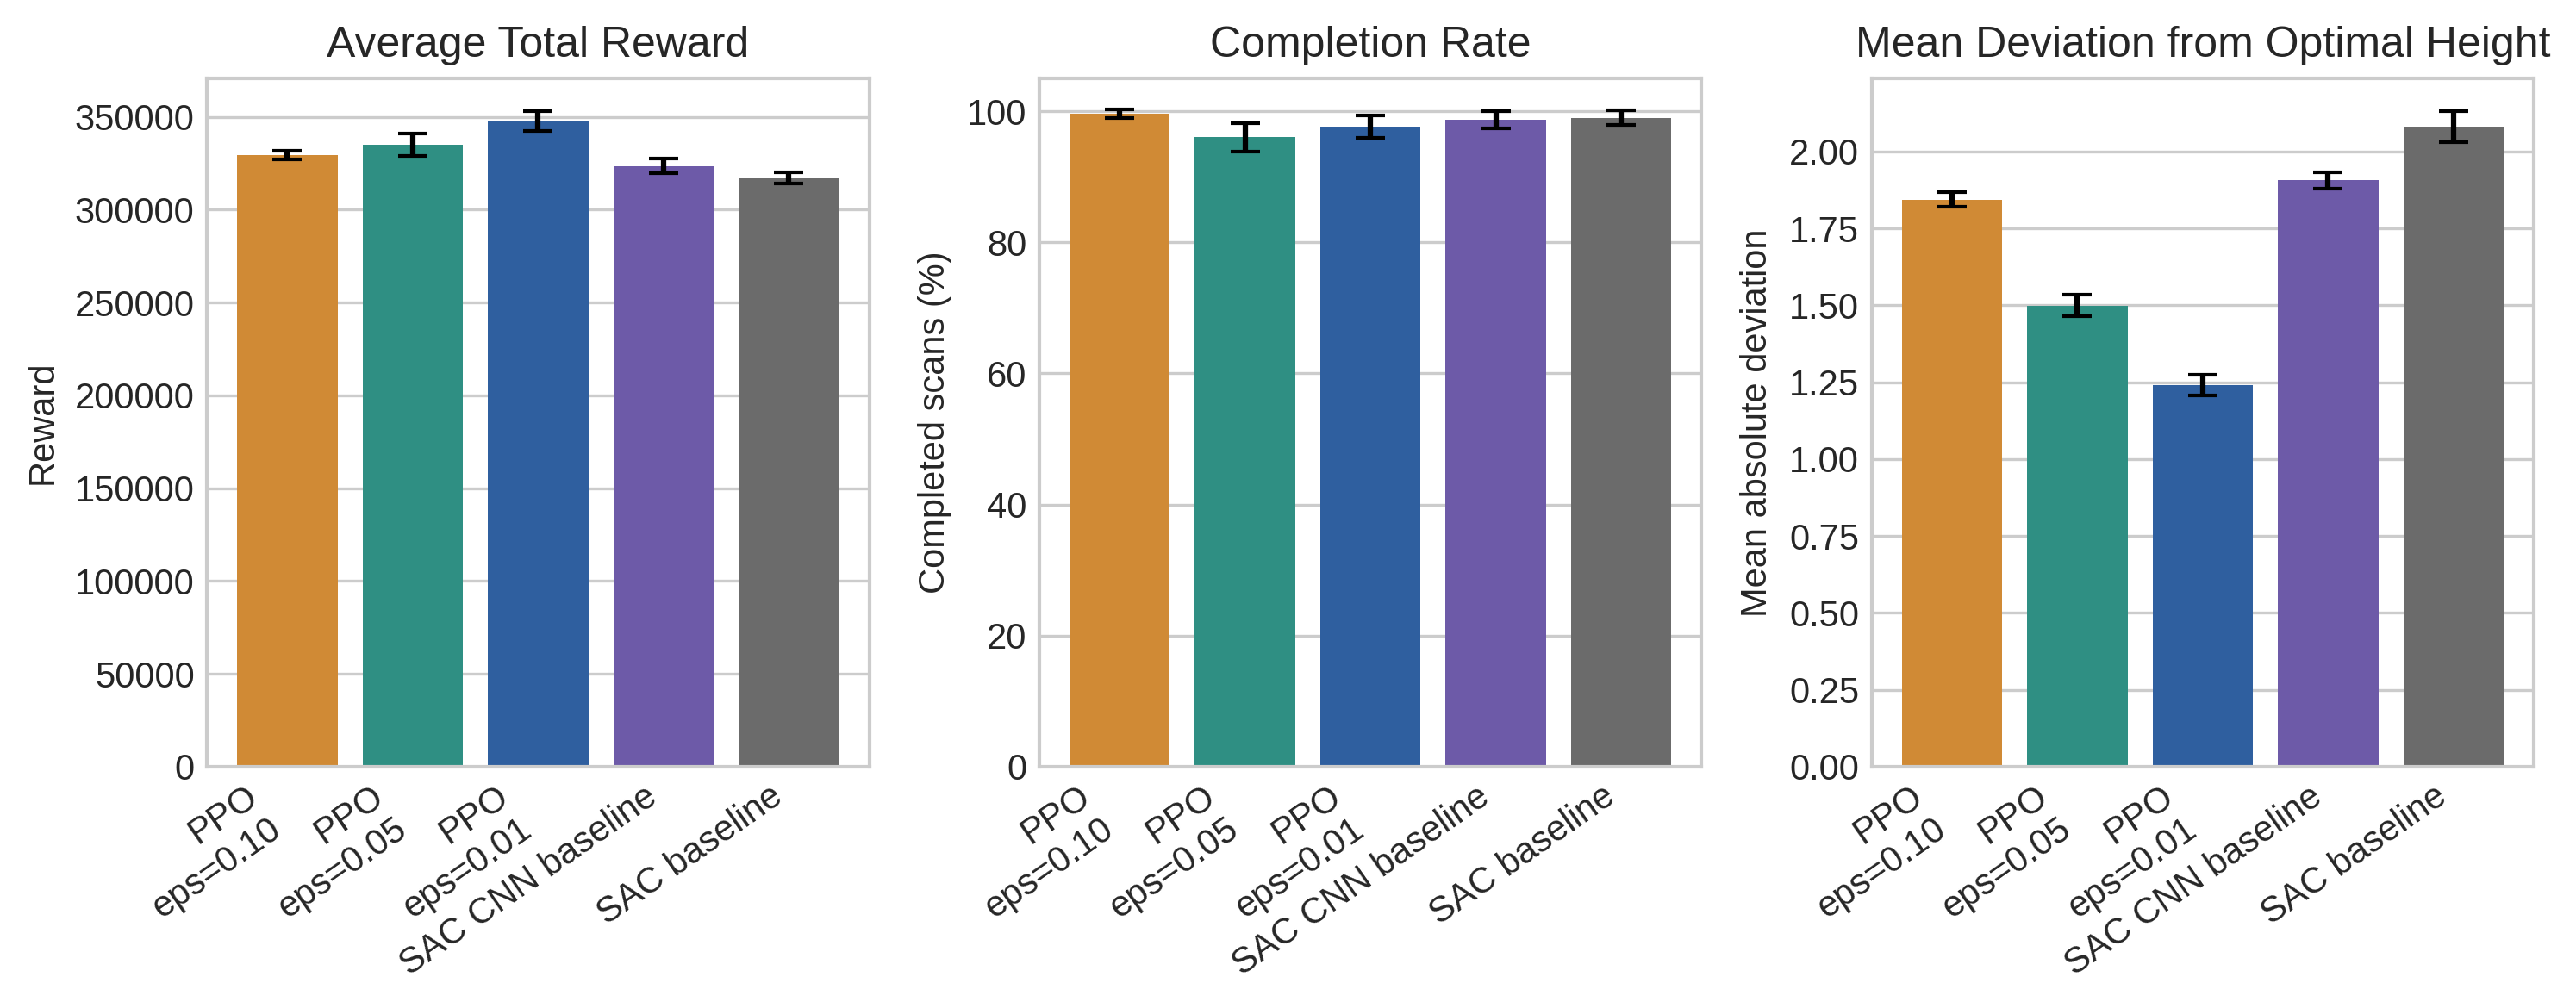

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4), dpi=300)
x = np.arange(len(stage_summary))
labels = [label.replace("PPO staged ", "PPO\n") for label in stage_summary.index]
colors = [PLOT_COLORS[idx] for idx in stage_summary.index]

axes[0].bar(x, stage_summary["avg_reward"], yerr=stage_summary["reward_ci95"], color=colors, capsize=4)
axes[0].set_title("Average Total Reward")
axes[0].set_ylabel("Reward")

axes[1].bar(x, stage_summary["completion_pct"], yerr=stage_summary["completion_ci95"], color=colors, capsize=4)
axes[1].set_title("Completion Rate")
axes[1].set_ylabel("Completed scans (%)")
axes[1].set_ylim(0, 105)

axes[2].bar(x, stage_summary["mean_deviation"], yerr=stage_summary["mean_deviation_ci95"], color=colors, capsize=4)
axes[2].set_title("Mean Deviation from Optimal Height")
axes[2].set_ylabel("Mean absolute deviation")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

## Surface-wise Breakdown

In [8]:
surface_summary = (
    summary.groupby(["stage", "surface_label"], observed=True)
    .agg(
        episodes=("total_reward", "size"),
        avg_reward=("total_reward", "mean"),
        completion_pct=("completed", lambda s: s.mean() * 100),
        mean_deviation=("mean_deviation", "mean"),
        danger_pct=("pct_danger", "mean"),
    )
    .reset_index()
)

display(
    surface_summary.sort_values(["stage", "surface_label"]).style.format(
        {
            "avg_reward": "{:.1f}",
            "completion_pct": "{:.1f}%",
            "mean_deviation": "{:.3f}",
            "danger_pct": "{:.3f}%",
        }
    )
)

,stage,surface_label,episodes,avg_reward,completion_pct,mean_deviation,danger_pct
0,PPO staged eps=0.10,1A,60,329280.5,100.0%,1.874,0.001%
1,PPO staged eps=0.10,2V,60,332395.7,100.0%,1.797,0.000%
2,PPO staged eps=0.10,2V + 1A,60,324687.7,98.3%,1.854,0.025%
3,PPO staged eps=0.10,3V + 1A,60,330841.3,100.0%,1.835,0.002%
4,PPO staged eps=0.10,Plateau,60,329773.3,100.0%,1.862,0.000%
5,PPO staged eps=0.05,1A,60,344320.5,100.0%,1.501,0.004%
6,PPO staged eps=0.05,2V,60,346993.6,100.0%,1.430,0.029%
7,PPO staged eps=0.05,2V + 1A,60,334845.5,96.7%,1.480,0.014%
8,PPO staged eps=0.05,3V + 1A,60,329462.0,95.0%,1.452,0.084%
9,PPO staged eps=0.05,Plateau,60,319243.6,88.3%,1.632,0.061%


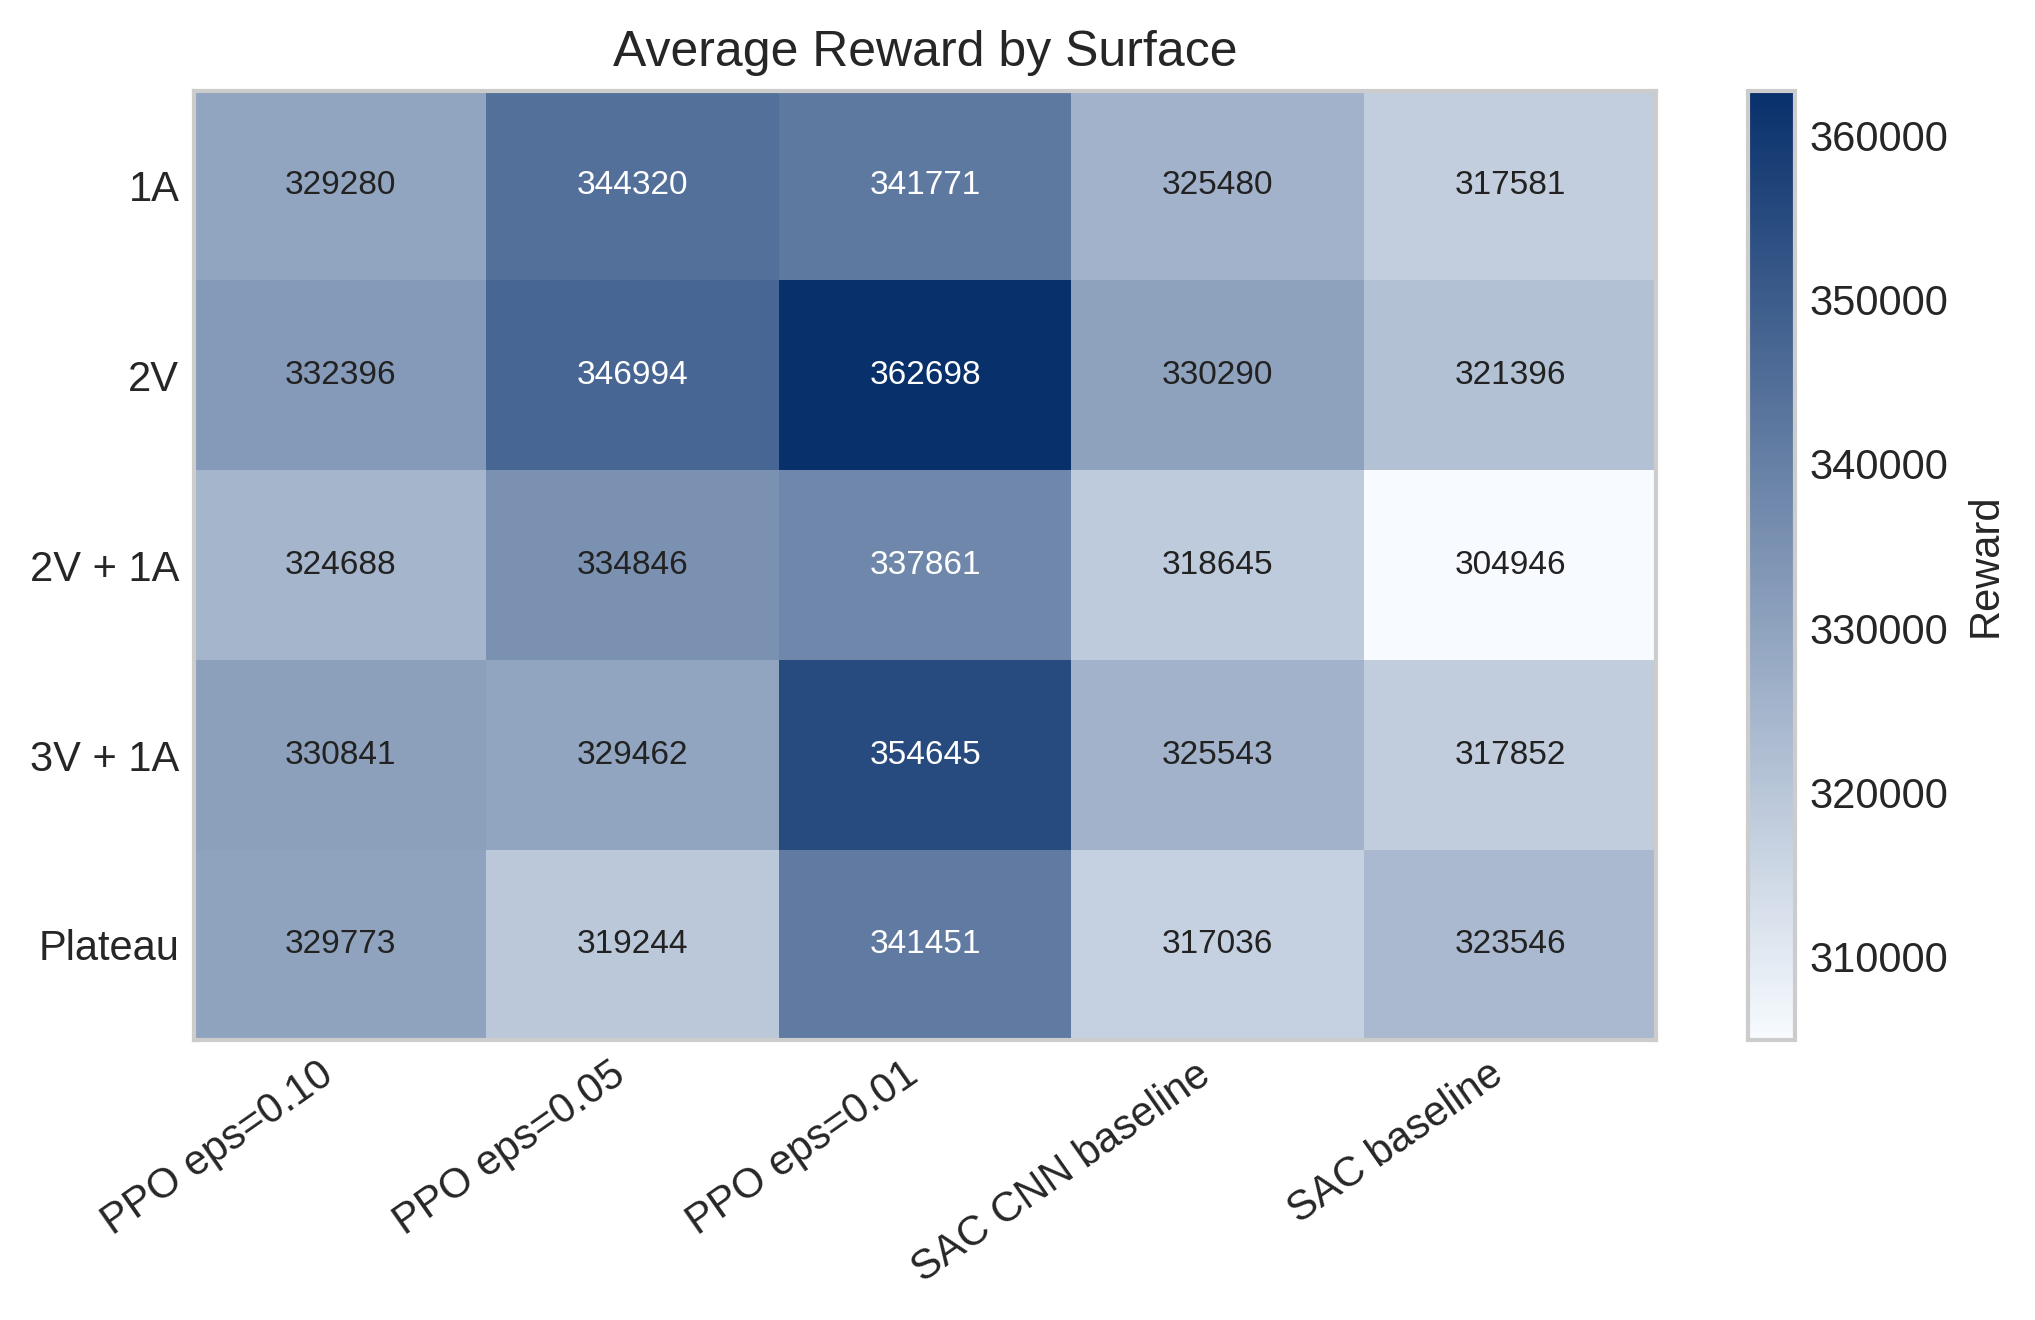

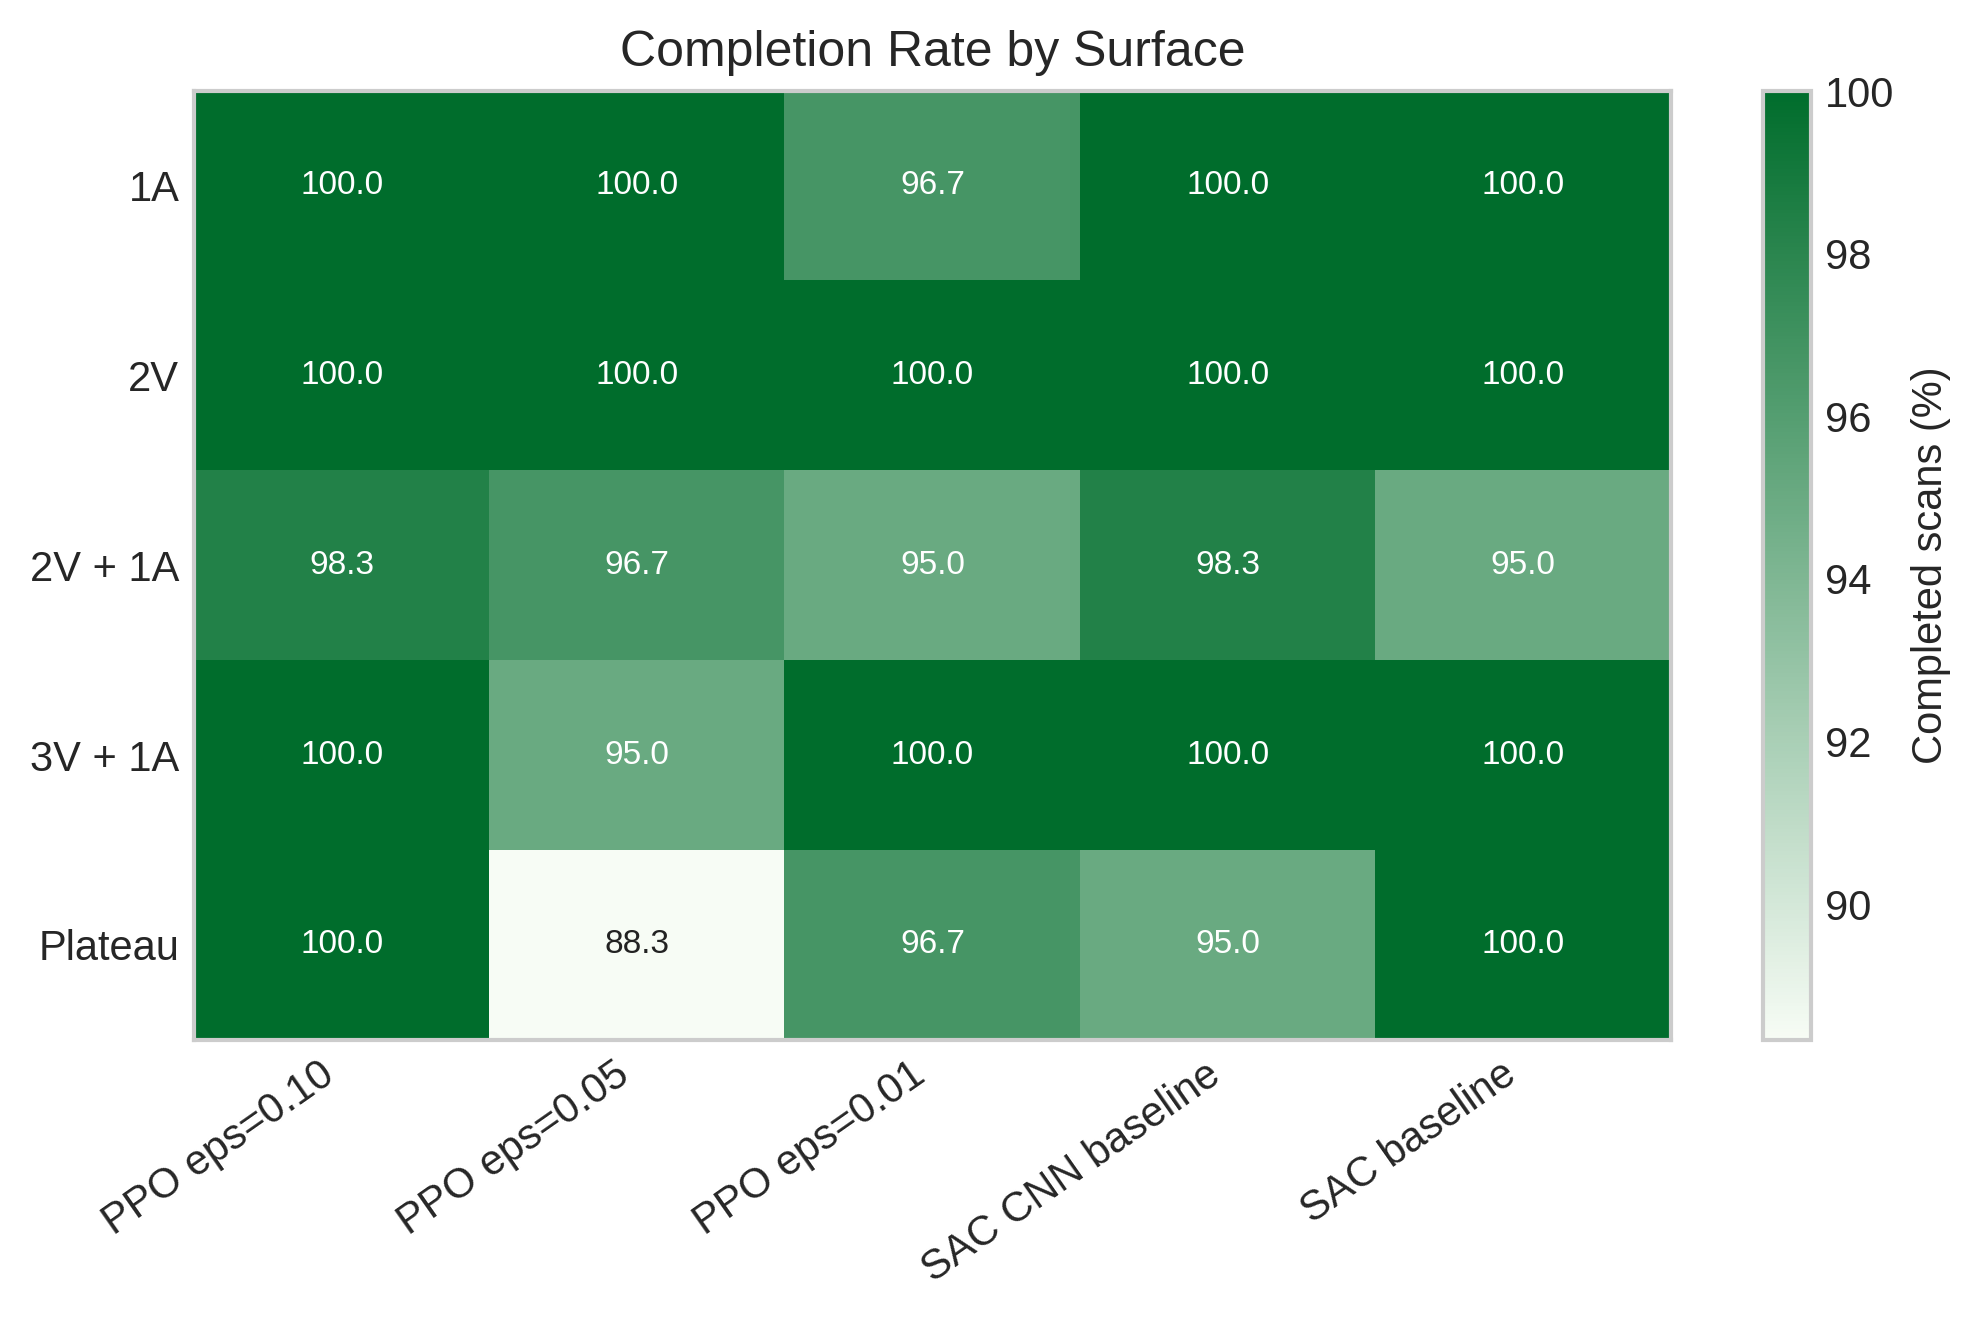

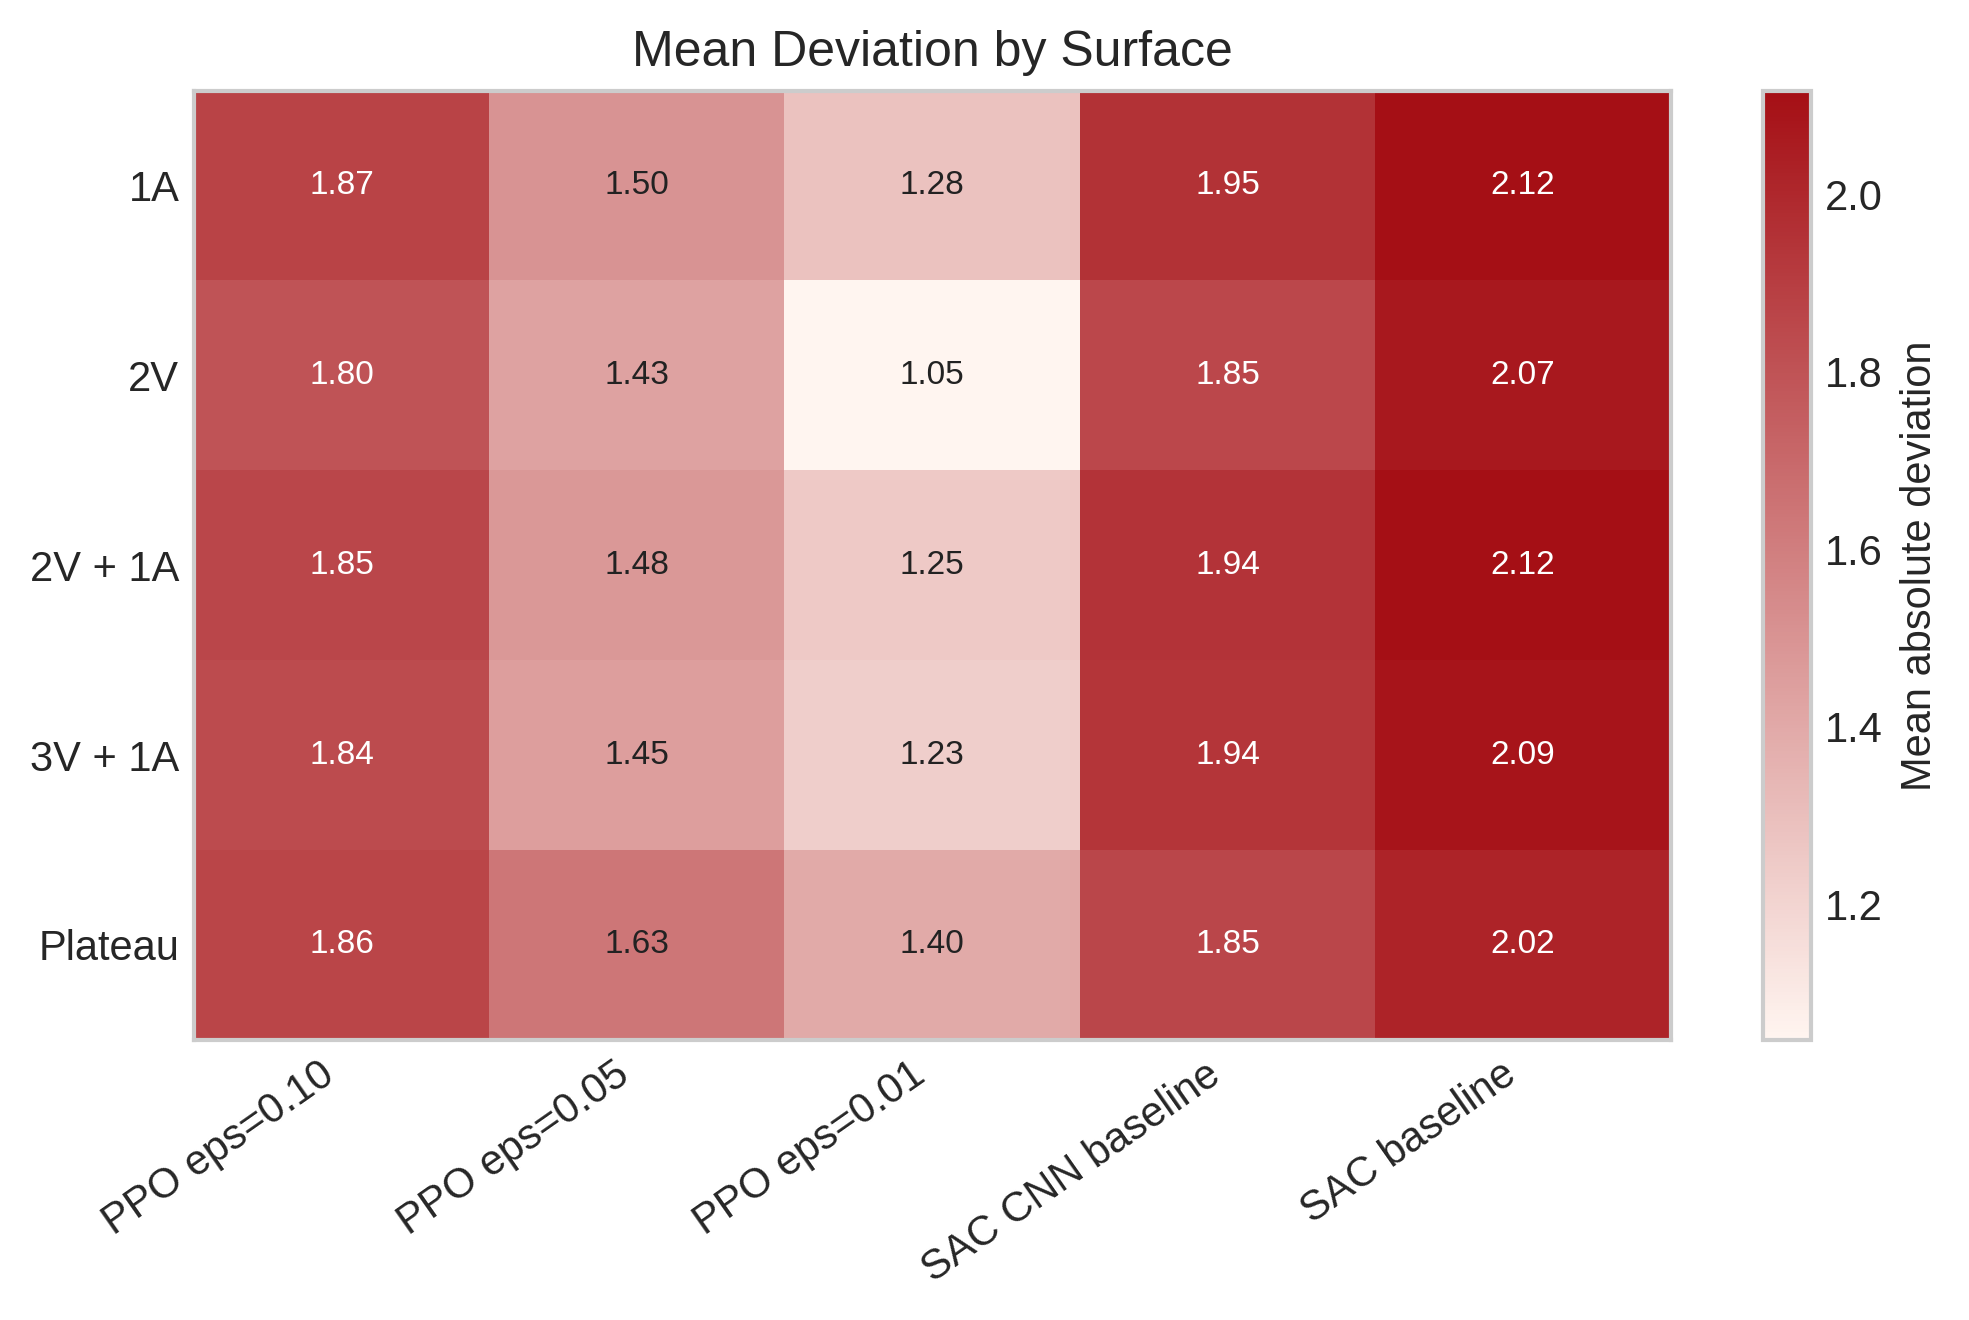

In [9]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

LINEAR_HEATMAP_CMAPS = {
    "reward_linear": LinearSegmentedColormap.from_list("reward_linear", ["#f7fbff", "#08306b"]),
    "completion_linear": LinearSegmentedColormap.from_list("completion_linear", ["#f7fcf5", "#006d2c"]),
    "deviation_linear": LinearSegmentedColormap.from_list("deviation_linear", ["#fff5f0", "#a50f15"]),
}


def plot_metric_heatmap(metric: str, title: str, cbar_label: str, fmt: str = ".1f", cmap: str = "reward_linear"):
    pivot = surface_summary.pivot(index="surface_label", columns="stage", values=metric)
    pivot = pivot.reindex(columns=stage_order)

    values = pivot.to_numpy(dtype=float)
    finite_values = values[np.isfinite(values)]
    vmin, vmax = float(finite_values.min()), float(finite_values.max())
    if np.isclose(vmin, vmax):
        vmin -= 0.5
        vmax += 0.5
    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)
    im = ax.imshow(values, aspect="auto", cmap=LINEAR_HEATMAP_CMAPS.get(cmap, cmap), norm=norm, interpolation="nearest")
    ax.grid(False)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([c.replace("PPO staged ", "PPO ") for c in pivot.columns], rotation=35, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    for row in range(pivot.shape[0]):
        for col in range(pivot.shape[1]):
            value = pivot.iloc[row, col]
            if np.isfinite(value):
                text_color = "white" if norm(value) > 0.55 else "#222222"
                ax.text(col, row, format(value, fmt), ha="center", va="center", color=text_color, fontsize=8)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)
    fig.tight_layout()
    plt.show()


plot_metric_heatmap("avg_reward", "Average Reward by Surface", "Reward", fmt=".0f", cmap="reward_linear")
plot_metric_heatmap("completion_pct", "Completion Rate by Surface", "Completed scans (%)", fmt=".1f", cmap="completion_linear")
plot_metric_heatmap("mean_deviation", "Mean Deviation by Surface", "Mean absolute deviation", fmt=".2f", cmap="deviation_linear")

## Failure and Tail-risk Analysis

In [10]:
failure_summary = (
    summary.groupby("stage", observed=True)
    .agg(
        episodes=("total_reward", "size"),
        early_terminations=("terminated_early", "sum"),
        early_term_pct=("terminated_early", lambda s: s.mean() * 100),
        worst_reward=("total_reward", "min"),
        p05_reward=("total_reward", lambda s: s.quantile(0.05)),
        median_reward=("total_reward", "median"),
        p95_reward=("total_reward", lambda s: s.quantile(0.95)),
        shortest_episode=("episode_length", "min"),
    )
    .reindex(stage_order)
)

display(
    failure_summary.style.format(
        {
            "early_term_pct": "{:.1f}%",
            "worst_reward": "{:.1f}",
            "p05_reward": "{:.1f}",
            "median_reward": "{:.1f}",
            "p95_reward": "{:.1f}",
        }
    )
)

,episodes,early_terminations,early_term_pct,worst_reward,p05_reward,median_reward,p95_reward,shortest_episode
stage,,,,,,,,
PPO staged eps=0.10,300,1,0.3%,1436.2,316679.4,330274.8,346910.8,220
PPO staged eps=0.05,300,12,4.0%,1926.5,314410.6,342685.9,364652.4,248
PPO staged eps=0.01,300,7,2.3%,-225.1,323383.6,356350.9,367037.0,7
SAC CNN baseline,300,4,1.3%,6979.2,305768.4,326985.7,338495.5,1118
SAC baseline,300,3,1.0%,10907.4,293054.1,317999.3,346339.5,1739


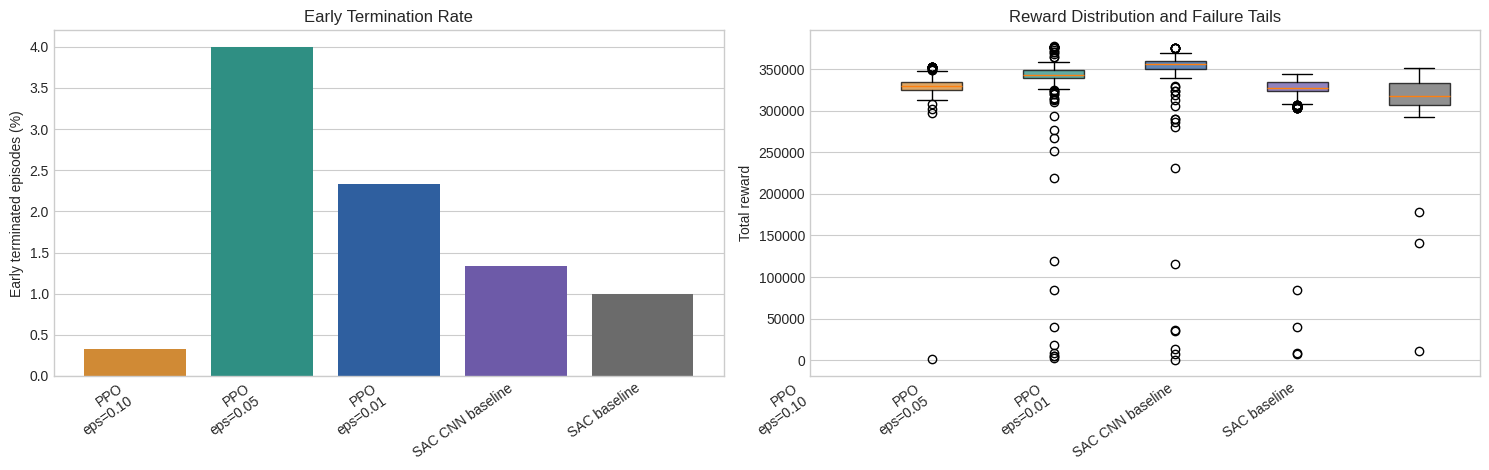

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
labels = [label.replace("PPO staged ", "PPO\n") for label in failure_summary.index]
colors = [PLOT_COLORS[idx] for idx in failure_summary.index]
x = np.arange(len(failure_summary))

axes[0].bar(x, failure_summary["early_term_pct"], color=colors)
axes[0].set_title("Early Termination Rate")
axes[0].set_ylabel("Early terminated episodes (%)")

reward_data = [summary.loc[summary["stage"] == stage, "total_reward"].values for stage in failure_summary.index]
box = axes[1].boxplot(reward_data, tick_labels=labels, showfliers=True, patch_artist=True)
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_title("Reward Distribution and Failure Tails")
axes[1].set_ylabel("Total reward")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

In [12]:
worst_episodes = (
    summary.sort_values("total_reward")
    .loc[:, [
        "agent",
        "stage",
        "surface_label",
        "view_idx",
        "total_reward",
        "episode_length",
        "terminated_early",
        "mean_deviation",
        "pct_danger",
        "pct_crash",
    ]]
    .head(20)
)

display(
    worst_episodes.style.format(
        {
            "total_reward": "{:.1f}",
            "mean_deviation": "{:.3f}",
            "pct_danger": "{:.2f}%",
            "pct_crash": "{:.2f}%",
        }
    )
)

,agent,stage,surface_label,view_idx,total_reward,episode_length,terminated_early,mean_deviation,pct_danger,pct_crash
260,PPO cnn eps0.01 #6,PPO staged eps=0.01,1A,320,-225.1,7,True,1.510,28.57%,14.29%
659,PPO cnn eps0.1 #2,PPO staged eps=0.10,2V + 1A,1511,1436.2,220,True,2.008,1.36%,0.45%
330,PPO cnn eps0.05 #1,PPO staged eps=0.05,3V + 1A,270,1926.5,248,True,1.367,0.81%,0.40%
337,PPO cnn eps0.05 #1,PPO staged eps=0.05,3V + 1A,1597,4502.4,668,True,1.344,3.59%,0.15%
559,PPO cnn eps0.05 #6,PPO staged eps=0.05,2V + 1A,1511,5173.7,618,True,1.300,0.32%,0.16%
1296,SAC cnn #2,SAC CNN baseline,Plateau,33,6979.2,1118,True,2.664,1.61%,0.09%
104,PPO cnn eps0.01 #3,PPO staged eps=0.01,2V + 1A,761,7731.9,931,True,1.286,0.43%,0.11%
548,PPO cnn eps0.05 #5,PPO staged eps=0.05,Plateau,43,8753.2,1115,True,1.619,1.26%,0.09%
1254,SAC cnn #2,SAC CNN baseline,2V + 1A,761,9006.1,1469,True,2.466,2.72%,0.07%
1754,SAC #6,SAC baseline,2V + 1A,761,10907.4,1739,True,2.289,2.19%,0.06%


## Image Figures

These plots use the existing raw evaluation pickle and pregenerated environment files. They do not run new agent evaluations.

In [13]:
from scipy.ndimage import gaussian_filter

_RAW_RESULTS_CACHE = None
_EPISODE_INDEX_CACHE = None
_IDEAL_IMAGE_CACHE = {}
_CONSTANT_IMAGE_CACHE = {}


def load_raw_results():
    """Load the saved raw evaluation results once per notebook session."""
    global _RAW_RESULTS_CACHE
    if _RAW_RESULTS_CACHE is None:
        with RAW_RESULTS_PATH.open("rb") as f:
            _RAW_RESULTS_CACHE = pickle.load(f)["all_results"]
    return _RAW_RESULTS_CACHE


def build_episode_index():
    """Create a lightweight table that links episode metadata to raw episode objects."""
    global _EPISODE_INDEX_CACHE
    if _EPISODE_INDEX_CACHE is not None:
        return _EPISODE_INDEX_CACHE

    rows = []
    for agent_name, episodes in load_raw_results().items():
        if not is_report_agent(agent_name):
            continue
        for episode_idx, episode in enumerate(episodes):
            rows.append(
                {
                    "agent": agent_name,
                    "stage": classify_agent(agent_name),
                    "episode_idx": episode_idx,
                    "surface": episode["surface_name"],
                    "surface_short": short_surface_name(episode["surface_name"]),
                    "surface_label": report_surface_name(episode["surface_name"]),
                    "view_idx": int(episode["view_idx"]),
                    "total_reward": float(episode["total_reward"]),
                    "episode_length": int(episode["episode_length"]),
                    "terminated_early": bool(episode["terminated_early"]),
                    "mean_deviation": float(episode["mean_deviation"]),
                    "episode": episode,
                }
            )

    episode_index = pd.DataFrame(rows)
    episode_index["stage"] = pd.Categorical(episode_index["stage"], categories=stage_order, ordered=True)
    _EPISODE_INDEX_CACHE = episode_index
    return episode_index


def get_view_dir(surface_dir: str, view_idx: int) -> Path:
    surface_path = Path(surface_dir)
    view_dirs = sorted([p for p in surface_path.iterdir() if p.name.startswith("view_") and p.is_dir()])
    if view_idx < 0 or view_idx >= len(view_dirs):
        raise ValueError(f"view_idx={view_idx} is outside [0, {len(view_dirs) - 1}] for {surface_dir}")
    return view_dirs[view_idx]


def interp_df_at_z(profile: np.ndarray, z_values: np.ndarray, z_target: float) -> float:
    """Interpolate one AFM z-profile at the requested physical height."""
    if z_values[0] > z_values[-1]:
        return float(np.interp(z_target, z_values[::-1], profile[::-1]))
    return float(np.interp(z_target, z_values, profile))


def compute_ideal_image(surface_dir: str, view_idx: int, sigma: int = IDEAL_IMAGE_SIGMA, height_offset: float = IDEAL_IMAGE_HEIGHT_OFFSET) -> np.ndarray:
    """Ideal image if the tip exactly follows the reward optimal-height surface."""
    cache_key = (surface_dir, int(view_idx), int(sigma), float(height_offset))
    if cache_key in _IDEAL_IMAGE_CACHE:
        return _IDEAL_IMAGE_CACHE[cache_key]

    view_dir = get_view_dir(surface_dir, int(view_idx))
    afm_images = np.load(view_dir / "afm_images.npy", mmap_mode="r")
    with np.load(view_dir / "meta.npz") as meta:
        z_axis = meta["z_height_map"].astype(float)
        min_image = meta["min_image"].astype(float)

    optimal_height = gaussian_filter(min_image, sigma=sigma) + height_offset
    ideal_image = np.empty(afm_images.shape[:2], dtype=np.float64)

    for x in range(afm_images.shape[0]):
        for y in range(afm_images.shape[1]):
            ideal_image[x, y] = interp_df_at_z(
                afm_images[x, y, :].astype(float),
                z_axis,
                float(optimal_height[x, y]),
            )

    _IDEAL_IMAGE_CACHE[cache_key] = ideal_image
    return ideal_image


def compute_safe_constant_height_image(surface_dir: str, view_idx: int, sigma: int = IDEAL_IMAGE_SIGMA, height_offset: float = IDEAL_IMAGE_HEIGHT_OFFSET, margin: float = CONSTANT_HEIGHT_MARGIN):
    """Constant-height reference image using a per-view safe z height."""
    cache_key = (surface_dir, int(view_idx), int(sigma), float(height_offset), float(margin))
    if cache_key in _CONSTANT_IMAGE_CACHE:
        return _CONSTANT_IMAGE_CACHE[cache_key]

    view_dir = get_view_dir(surface_dir, int(view_idx))
    afm_images = np.load(view_dir / "afm_images.npy", mmap_mode="r")
    with np.load(view_dir / "meta.npz") as meta:
        z_axis = meta["z_height_map"].astype(float)
        min_image = meta["min_image"].astype(float)

    optimal_height = gaussian_filter(min_image, sigma=sigma) + height_offset
    z_const = max(float(np.nanmax(min_image)), float(np.nanmax(optimal_height))) + margin
    constant_image = np.empty(afm_images.shape[:2], dtype=np.float64)

    for x in range(afm_images.shape[0]):
        for y in range(afm_images.shape[1]):
            constant_image[x, y] = interp_df_at_z(
                afm_images[x, y, :].astype(float),
                z_axis,
                z_const,
            )

    _CONSTANT_IMAGE_CACHE[cache_key] = (constant_image, z_const)
    return constant_image, z_const


def robust_image_limits(images, lower: float = 2, upper: float = 98):
    finite_values = []
    for image in images:
        arr = np.asarray(image, dtype=float)
        finite_values.append(arr[np.isfinite(arr)].ravel())
    finite_values = [v for v in finite_values if len(v)]
    if not finite_values:
        return 0.0, 1.0
    finite_values = np.concatenate(finite_values)
    vmin, vmax = np.percentile(finite_values, [lower, upper])
    if np.isclose(vmin, vmax):
        vmin -= 0.5
        vmax += 0.5
    return vmin, vmax



def select_high_reward_case(episode_index: pd.DataFrame, stage: str):
    """Select the highest-reward completed episode for a method."""
    candidates = episode_index.loc[
        (episode_index["stage"] == stage)
        & (~episode_index["terminated_early"])
    ].copy()
    if candidates.empty:
        raise ValueError(f"No completed episodes found for stage={stage}")

    return candidates.sort_values(["total_reward", "mean_deviation"], ascending=[False, True]).iloc[0]


def plot_image_grid(images, titles, ncols: int, suptitle: str, filename: str | None = None, shared_color_scale: bool = False):
    n_images = len(images)
    nrows = int(np.ceil(n_images / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.7 * ncols, 3.8 * nrows), squeeze=False)
    axes_flat = axes.ravel()

    cmap = plt.get_cmap("cividis").copy()
    cmap.set_bad("#e8e8e8")
    shared_vmin, shared_vmax = robust_image_limits(images)

    image_handles = []
    for ax, image, title in zip(axes_flat, images, titles):
        arr = np.asarray(image, dtype=float)
        masked = np.ma.masked_invalid(arr.T)
        if shared_color_scale:
            vmin, vmax = shared_vmin, shared_vmax
        else:
            vmin, vmax = robust_image_limits([arr])
        im = ax.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax)
        image_handles.append((ax, im))
        ax.set_title(title, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes_flat[n_images:]:
        ax.axis("off")

    fig.suptitle(suptitle, fontsize=13, y=0.98)
    if shared_color_scale:
        fig.colorbar(image_handles[-1][1], ax=axes_flat[:n_images].tolist(), shrink=0.75, label="df")
    else:
        for ax, im in image_handles:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

    if SAVE_EVALUATION_FIGURES and filename is not None:
        EVALUATION_FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(EVALUATION_FIG_DIR / filename, dpi=250, bbox_inches="tight")

    plt.show()
    return fig


def representative_view_from_stage(stage: str = "PPO staged eps=0.01"):
    stage_rows = summary.loc[summary["stage"] == stage].copy()
    median_reward = stage_rows["total_reward"].median()
    selected_idx = (stage_rows["total_reward"] - median_reward).abs().idxmin()
    selected = stage_rows.loc[selected_idx]
    return selected["surface"], int(selected["view_idx"])


def representative_episode_for_view(episode_index: pd.DataFrame, stage: str, surface: str, view_idx: int):
    candidates = episode_index.loc[
        (episode_index["stage"] == stage)
        & (episode_index["surface"] == surface)
        & (episode_index["view_idx"] == int(view_idx))
    ].copy()
    if candidates.empty:
        raise ValueError(f"No episode found for stage={stage}, surface={surface}, view_idx={view_idx}")
    median_reward = candidates["total_reward"].median()
    selected_idx = (candidates["total_reward"] - median_reward).abs().idxmin()
    return candidates.loc[selected_idx]


def select_stage_case(episode_index: pd.DataFrame, stage: str, case: str):
    candidates = episode_index.loc[episode_index["stage"] == stage].copy()
    if case == "best":
        return candidates.loc[candidates["total_reward"].idxmax()]
    if case == "worst":
        return candidates.loc[candidates["total_reward"].idxmin()]
    if case == "median":
        median_reward = candidates["total_reward"].median()
        selected_idx = (candidates["total_reward"] - median_reward).abs().idxmin()
        return candidates.loc[selected_idx]
    raise ValueError(f"Unknown case: {case}")

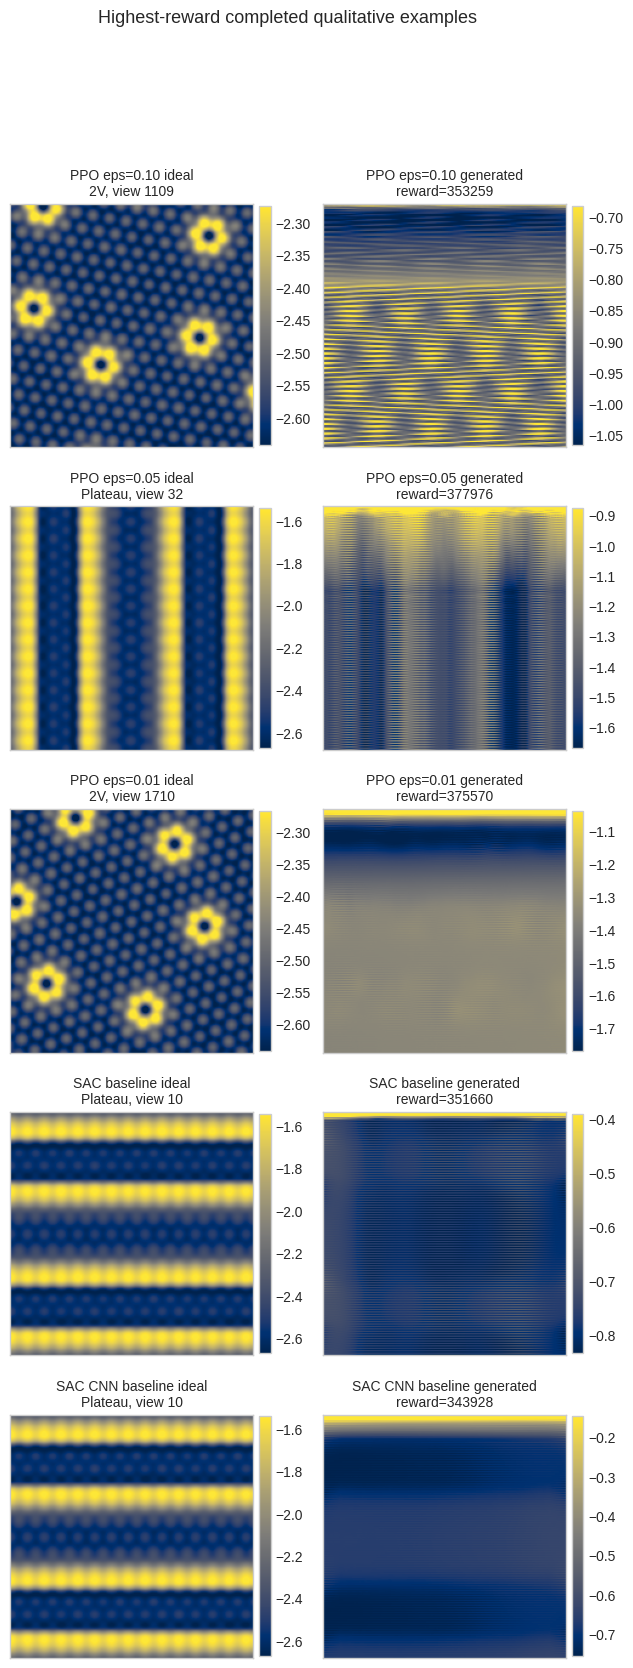

,agent,stage,surface_label,view_idx,total_reward,episode_length,mean_deviation
825,PPO cnn eps0.1 #5,PPO staged eps=0.10,2V,1109,353258.8,40400,1.281
545,PPO cnn eps0.05 #5,PPO staged eps=0.05,Plateau,32,377976.1,40400,0.608
129,PPO cnn eps0.01 #3,PPO staged eps=0.01,2V,1710,375570.3,40400,0.728
1491,SAC #6,SAC baseline,Plateau,10,351660.0,40400,1.320
1141,SAC cnn #5,SAC CNN baseline,Plateau,10,343928.1,40400,1.512


In [14]:
if RUN_IMAGE_FIGURES:
    episode_index = build_episode_index()
    selected_rows = [
        select_high_reward_case(episode_index, stage)
        for stage in IMAGE_COMPARISON_STAGES
    ]

    # Reuse the final-PPO selected view for the df(z) reference curve below.
    final_reference_row = next(row for row in selected_rows if row["stage"] == "PPO staged eps=0.01")
    comparison_surface = final_reference_row["surface"]
    comparison_view = int(final_reference_row["view_idx"])

    images = []
    titles = []
    for row in selected_rows:
        ideal = compute_ideal_image(row["surface"], int(row["view_idx"]))
        generated = np.asarray(row["episode"]["generated_image"], dtype=float)
        label = str(row["stage"]).replace("PPO staged ", "PPO ")
        images.extend([ideal, generated])
        titles.extend(
            [
                f"{label} ideal\n{row['surface_label']}, view {int(row['view_idx'])}",
                f"{label} generated\nreward={row['total_reward']:.0f}",
            ]
        )

    plot_image_grid(
        images,
        titles,
        ncols=2,
        suptitle="Highest-reward completed qualitative examples",
        filename="high_reward_visual_examples.png",
        shared_color_scale=False,
    )

    visual_examples_table = pd.DataFrame(selected_rows).drop(columns=["episode"])
    display(
        visual_examples_table.loc[:, ["agent", "stage", "surface_label", "view_idx", "total_reward", "episode_length", "mean_deviation"]]
        .style.format({"total_reward": "{:.1f}", "mean_deviation": "{:.3f}"})
    )
else:
    print("Image figure generation skipped because RUN_IMAGE_FIGURES is False.")

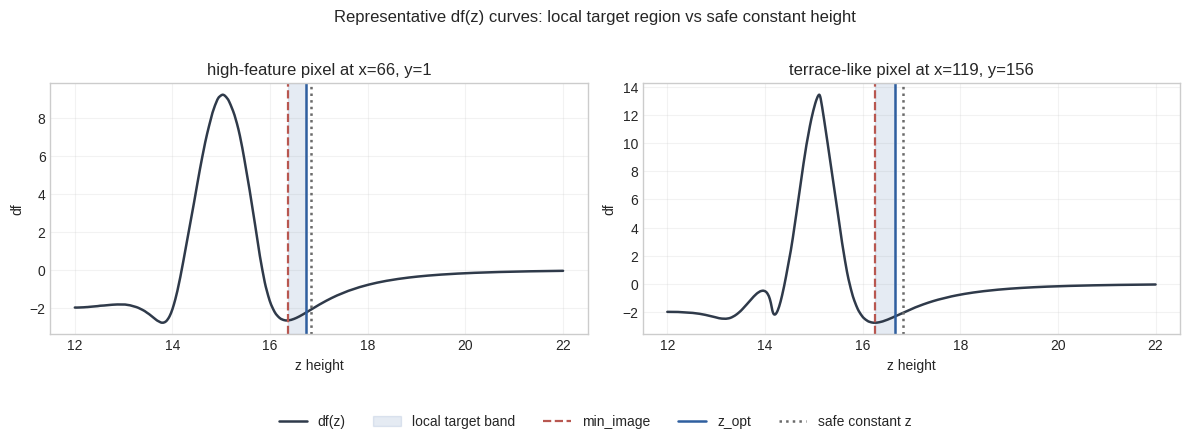

In [15]:
if RUN_IMAGE_FIGURES:
    if "comparison_surface" not in globals() or "comparison_view" not in globals():
        episode_index = build_episode_index()
        final_reference_row = select_high_reward_case(episode_index, "PPO staged eps=0.01")
        comparison_surface = final_reference_row["surface"]
        comparison_view = int(final_reference_row["view_idx"])

    view_dir = get_view_dir(comparison_surface, comparison_view)
    afm_images = np.load(view_dir / "afm_images.npy", mmap_mode="r")
    with np.load(view_dir / "meta.npz") as meta:
        z_axis = meta["z_height_map"].astype(float)
        min_image = meta["min_image"].astype(float)

    optimal_height = gaussian_filter(min_image, sigma=IDEAL_IMAGE_SIGMA) + IDEAL_IMAGE_HEIGHT_OFFSET
    _, z_const = compute_safe_constant_height_image(comparison_surface, comparison_view)

    feature_xy = np.unravel_index(np.nanargmax(optimal_height), optimal_height.shape)
    median_height = np.nanmedian(optimal_height)
    terrace_xy = np.unravel_index(np.nanargmin(np.abs(optimal_height - median_height)), optimal_height.shape)
    curve_points = [("high-feature pixel", feature_xy), ("terrace-like pixel", terrace_xy)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for ax, (label, (x, y)) in zip(axes, curve_points):
        profile = afm_images[x, y, :].astype(float)
        order = np.argsort(z_axis)
        z_plot = z_axis[order]
        profile_plot = profile[order]
        z_min = float(min_image[x, y])
        z_opt = float(optimal_height[x, y])

        ax.plot(z_plot, profile_plot, color="#2f3a4a", linewidth=1.8, label="df(z)")
        ax.axvspan(min(z_min, z_opt), max(z_min, z_opt), color="#2f5f9f", alpha=0.12, label="local target band")
        ax.axvline(z_min, color="#b85750", linestyle="--", linewidth=1.6, label="min_image")
        ax.axvline(z_opt, color="#2f5f9f", linestyle="-", linewidth=1.8, label="z_opt")
        ax.axvline(z_const, color="#6b6b6b", linestyle=":", linewidth=1.8, label="safe constant z")
        ax.set_title(f"{label} at x={x}, y={y}")
        ax.set_xlabel("z height")
        ax.set_ylabel("df")
        ax.grid(True, alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False)
    fig.suptitle("Representative df(z) curves: local target region vs safe constant height", y=1.02)
    fig.tight_layout(rect=[0, 0.12, 1, 1])

    if SAVE_EVALUATION_FIGURES:
        EVALUATION_FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(EVALUATION_FIG_DIR / "df_curve_reference_region.png", dpi=250, bbox_inches="tight")

    plt.show()
else:
    print("df(z) curve figure skipped because RUN_IMAGE_FIGURES is False.")

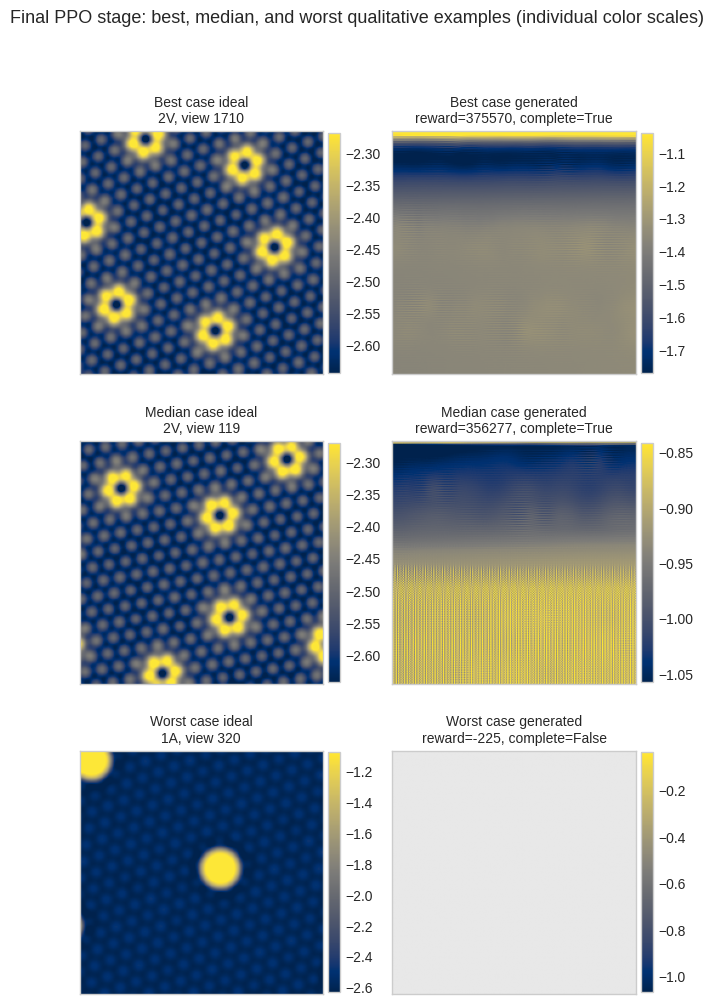

,case,agent,surface_label,view_idx,total_reward,episode_length,terminated_early,mean_deviation
129,best,PPO cnn eps0.01 #3,2V,1710,375570.3,40400,False,0.728
20,median,PPO cnn eps0.01 #1,2V,119,356277.4,40400,False,1.206
260,worst,PPO cnn eps0.01 #6,1A,320,-225.1,7,True,1.510


In [16]:
if RUN_IMAGE_FIGURES:
    episode_index = build_episode_index()
    final_stage = "PPO staged eps=0.01"
    cases = ["best", "median", "worst"]
    selected_cases = [select_stage_case(episode_index, final_stage, case) for case in cases]

    images = []
    titles = []
    for case, row in zip(cases, selected_cases):
        ideal = compute_ideal_image(row["surface"], int(row["view_idx"]))
        generated = np.asarray(row["episode"]["generated_image"], dtype=float)
        images.extend([ideal, generated])
        titles.extend(
            [
                f"{case.title()} case ideal\n{row['surface_label']}, view {int(row['view_idx'])}",
                f"{case.title()} case generated\nreward={row['total_reward']:.0f}, complete={not row['terminated_early']}",
            ]
        )

    plot_image_grid(
        images,
        titles,
        ncols=2,
        suptitle="Final PPO stage: best, median, and worst qualitative examples (individual color scales)",
        filename="final_ppo_best_median_worst.png",
        shared_color_scale=False,
    )

    case_table = pd.DataFrame(selected_cases).drop(columns=["episode"])
    case_table.insert(0, "case", cases)
    display(
        case_table.loc[:, ["case", "agent", "surface_label", "view_idx", "total_reward", "episode_length", "terminated_early", "mean_deviation"]]
        .style.format({"total_reward": "{:.1f}", "mean_deviation": "{:.3f}"})
    )
else:
    print("Final PPO case images skipped because RUN_IMAGE_FIGURES is False.")

In [17]:
# # Disk-based browser for every generated image.
# # This saves paginated grids instead of rendering hundreds of images inline.
# RUN_ALL_IMAGE_BROWSER = True
# ALL_IMAGE_BROWSER_ROOT = EVALUATION_FIG_DIR / "all_generated_image_browser"
# ALL_IMAGE_BROWSER_RUN_NAME = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
# ALL_IMAGE_BROWSER_PAIRS_PER_ROW = 3  # 3 pairs per row = 6 image columns.
# ALL_IMAGE_BROWSER_PAIRS_PER_PAGE = 24
# ALL_IMAGE_BROWSER_DPI = 140
# ALL_IMAGE_BROWSER_MAX_EPISODES = None
# ALL_IMAGE_BROWSER_GROUP_BY = "stage"

# import html
# import math
# import textwrap
# from IPython.display import display


# def _browser_slug(value: str) -> str:
#     slug = re.sub(r"[^A-Za-z0-9]+", "_", str(value)).strip("_").lower()
#     return slug or "group"


# def _wrap_browser_text(value, width: int = 32) -> str:
#     text = str(value)
#     wrapped = textwrap.wrap(text, width=width, break_long_words=False, replace_whitespace=False)
#     return "\n".join(wrapped) if wrapped else text


# def _complete_label(row) -> str:
#     return "complete" if not bool(row["terminated_early"]) else "incomplete"


# def _plot_browser_image(ax, image, title: str, cmap):
#     arr = np.asarray(image, dtype=float)
#     masked = np.ma.masked_invalid(arr.T)
#     vmin, vmax = robust_image_limits([arr])
#     ax.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
#     ax.set_title(title, fontsize=7.5, pad=4)
#     ax.set_xticks([])
#     ax.set_yticks([])


# def save_all_image_browser_page(page_rows: pd.DataFrame, page_path: Path, page_title: str):
#     pairs_per_row = int(ALL_IMAGE_BROWSER_PAIRS_PER_ROW)
#     image_cols = pairs_per_row * 2
#     n_pairs = len(page_rows)
#     nrows = int(math.ceil(n_pairs / pairs_per_row))

#     fig, axes = plt.subplots(
#         nrows,
#         image_cols,
#         figsize=(3.15 * image_cols, 3.45 * nrows + 0.7),
#         squeeze=False,
#     )
#     for ax in axes.ravel():
#         ax.axis("off")

#     cmap = plt.get_cmap("cividis").copy()
#     cmap.set_bad("#eeeeee")

#     for pair_idx, (_, row) in enumerate(page_rows.iterrows()):
#         grid_row = pair_idx // pairs_per_row
#         grid_col = (pair_idx % pairs_per_row) * 2

#         generated = np.asarray(row["episode"]["generated_image"], dtype=float)
#         try:
#             ideal = compute_ideal_image(row["surface"], int(row["view_idx"]))
#             ideal_note = "optimal height"
#         except Exception as exc:
#             ideal = np.full_like(generated, np.nan, dtype=float)
#             ideal_note = f"optimal height failed: {type(exc).__name__}"

#         stage_label = str(row["stage"]).replace("PPO staged ", "PPO ")
#         ideal_title = (
#             f"{ideal_note}\n"
#             f"{row['surface_short']}, view={int(row['view_idx'])}"
#         )
#         generated_title = (
#             f"{_wrap_browser_text(stage_label, 30)}\n"
#             f"{_wrap_browser_text(row['agent'], 32)}\n"
#             f"R={row['total_reward']:.0f}, {_complete_label(row)}, len={int(row['episode_length'])}\n"
#             f"dev={row['mean_deviation']:.3f}, ep={int(row['episode_idx'])}"
#         )

#         _plot_browser_image(axes[grid_row, grid_col], ideal, ideal_title, cmap)
#         _plot_browser_image(axes[grid_row, grid_col + 1], generated, generated_title, cmap)

#     fig.suptitle(page_title, fontsize=12, y=0.995)
#     fig.tight_layout(rect=(0, 0, 1, 0.985))
#     page_path.parent.mkdir(parents=True, exist_ok=True)
#     fig.savefig(page_path, dpi=int(ALL_IMAGE_BROWSER_DPI), bbox_inches="tight")
#     plt.close(fig)


# if RUN_ALL_IMAGE_BROWSER:
#     episode_index = build_episode_index().copy()
#     episode_index["stage"] = episode_index["stage"].astype(str)
#     episode_index["complete"] = ~episode_index["terminated_early"]

#     stage_order_lookup = {stage: idx for idx, stage in enumerate(STAGE_ORDER)}
#     episode_index["stage_sort"] = episode_index["stage"].map(stage_order_lookup).fillna(len(stage_order_lookup)).astype(int)
#     episode_index = episode_index.sort_values(
#         ["stage_sort", "agent", "surface_short", "view_idx", "episode_idx"],
#         kind="mergesort",
#     ).reset_index(drop=True)

#     if ALL_IMAGE_BROWSER_MAX_EPISODES is not None:
#         episode_index = episode_index.head(int(ALL_IMAGE_BROWSER_MAX_EPISODES)).copy()

#     output_dir = ALL_IMAGE_BROWSER_ROOT / ALL_IMAGE_BROWSER_RUN_NAME
#     output_dir.mkdir(parents=True, exist_ok=True)

#     if ALL_IMAGE_BROWSER_GROUP_BY == "stage":
#         present_stages = set(episode_index["stage"])
#         ordered_groups = [stage for stage in STAGE_ORDER if stage in present_stages]
#         ordered_groups += sorted(present_stages - set(ordered_groups))
#         groups = [(label, episode_index.loc[episode_index["stage"] == label].copy()) for label in ordered_groups]
#     else:
#         groups = [("all_agents", episode_index)]

#     total_pages = sum(int(math.ceil(len(group_df) / ALL_IMAGE_BROWSER_PAIRS_PER_PAGE)) for _, group_df in groups)
#     page_records = []
#     episode_records = []
#     global_page = 0

#     print(f"Saving {len(episode_index)} episode image pairs into {total_pages} page(s).", flush=True)
#     print(f"Output directory: {output_dir}", flush=True)

#     for group_label, group_df in groups:
#         group_slug = _browser_slug(group_label)
#         group_dir = output_dir / group_slug
#         n_group_pages = int(math.ceil(len(group_df) / ALL_IMAGE_BROWSER_PAIRS_PER_PAGE))

#         for page_idx, start in enumerate(range(0, len(group_df), ALL_IMAGE_BROWSER_PAIRS_PER_PAGE), start=1):
#             global_page += 1
#             page_df = group_df.iloc[start:start + ALL_IMAGE_BROWSER_PAIRS_PER_PAGE].copy()
#             page_path = group_dir / f"page_{page_idx:03d}.png"
#             page_title = (
#                 f"{group_label} | page {page_idx}/{n_group_pages} | "
#                 f"episodes {start + 1}-{start + len(page_df)} of {len(group_df)}"
#             )
#             print(f"[{global_page}/{total_pages}] saving {page_path.relative_to(output_dir)}", flush=True)
#             save_all_image_browser_page(page_df, page_path, page_title)

#             rel_page_path = page_path.relative_to(output_dir).as_posix()
#             page_records.append(
#                 {
#                     "group": group_label,
#                     "page_in_group": page_idx,
#                     "global_page": global_page,
#                     "episodes_on_page": len(page_df),
#                     "relative_path": rel_page_path,
#                     "file_path": str(page_path),
#                 }
#             )

#             for pair_position, (_, row) in enumerate(page_df.iterrows(), start=1):
#                 episode_records.append(
#                     {
#                         "group": group_label,
#                         "page_in_group": page_idx,
#                         "global_page": global_page,
#                         "pair_position_on_page": pair_position,
#                         "page_file": rel_page_path,
#                         "agent": row["agent"],
#                         "stage": row["stage"],
#                         "surface_short": row["surface_short"],
#                         "surface": row["surface"],
#                         "view_idx": int(row["view_idx"]),
#                         "episode_idx": int(row["episode_idx"]),
#                         "total_reward": float(row["total_reward"]),
#                         "episode_length": int(row["episode_length"]),
#                         "complete": bool(row["complete"]),
#                         "terminated_early": bool(row["terminated_early"]),
#                         "mean_deviation": float(row["mean_deviation"]),
#                     }
#                 )

#     pages_df = pd.DataFrame(page_records)
#     episodes_df = pd.DataFrame(episode_records)
#     pages_df.to_csv(output_dir / "pages.csv", index=False)
#     episodes_df.to_csv(output_dir / "episodes.csv", index=False)

#     html_lines = [
#         "<!doctype html>",
#         "<html><head><meta charset='utf-8'>",
#         "<title>All Generated Image Browser</title>",
#         "<style>body{font-family:Arial,sans-serif;margin:24px;} img{max-width:100%;height:auto;border:1px solid #ccc;} section{margin:0 0 32px;} code{background:#f4f4f4;padding:2px 4px;}</style>",
#         "</head><body>",
#         "<h1>All Generated Image Browser</h1>",
#         f"<p>Saved {len(episode_index)} episode pairs across {len(pages_df)} page(s). Each pair is shown as optimal-height image followed by generated image.</p>",
#         "<p>Metadata: <a href='pages.csv'>pages.csv</a> and <a href='episodes.csv'>episodes.csv</a>.</p>",
#     ]
#     for record in page_records:
#         rel_path = html.escape(record["relative_path"])
#         title = html.escape(f"{record['group']} page {record['page_in_group']} ({record['episodes_on_page']} episodes)")
#         html_lines.extend(
#             [
#                 "<section>",
#                 f"<h2>{title}</h2>",
#                 f"<p><code>{rel_path}</code></p>",
#                 f"<img src='{rel_path}' alt='{title}'>",
#                 "</section>",
#             ]
#         )
#     html_lines.append("</body></html>")
#     (output_dir / "index.html").write_text("\n".join(html_lines), encoding="utf-8")

#     print(f"Browser index: {output_dir / 'index.html'}", flush=True)
#     display(pages_df.head(12))
# else:
#     print("All-image browser skipped because RUN_ALL_IMAGE_BROWSER is False.")

## Optional Action Smoothness / Stability

This section uses the existing raw pickle, not a new experiment. It computes action smoothness and stability metrics from saved traces.

In [18]:
if RUN_RAW_TRACE_ANALYSIS:
    all_results_for_traces = load_raw_results()

    trace_rows = []
    for agent_name, episodes in all_results_for_traces.items():
        if not is_report_agent(agent_name):
            continue
        stage = classify_agent(agent_name)
        for episode_idx, episode in enumerate(episodes):
            actions = np.asarray(episode["actions"], dtype=np.float64)
            deviations = np.asarray(episode["deviation_from_optimal"], dtype=np.float64)
            action_diffs = np.diff(actions) if len(actions) > 1 else np.array([0.0])

            trace_rows.append(
                {
                    "agent": agent_name,
                    "stage": stage,
                    "episode_idx": episode_idx,
                    "mean_abs_action": float(np.mean(np.abs(actions))),
                    "std_action": float(np.std(actions)),
                    "mean_abs_action_change": float(np.mean(np.abs(action_diffs))),
                    "rmse_deviation": float(np.sqrt(np.mean(deviations ** 2))),
                    "q95_deviation": float(np.quantile(deviations, 0.95)),
                    "max_deviation": float(np.max(deviations)),
                }
            )

    trace_metrics = pd.DataFrame(trace_rows)
    trace_metrics["stage"] = pd.Categorical(trace_metrics["stage"], categories=stage_order, ordered=True)

    trace_summary = (
        trace_metrics.groupby("stage", observed=True)
        .agg(
            episodes=("episode_idx", "size"),
            mean_abs_action=("mean_abs_action", "mean"),
            mean_abs_action_ci95=("mean_abs_action", ci95),
            std_action=("std_action", "mean"),
            std_action_ci95=("std_action", ci95),
            mean_abs_action_change=("mean_abs_action_change", "mean"),
            mean_abs_action_change_ci95=("mean_abs_action_change", ci95),
            rmse_deviation=("rmse_deviation", "mean"),
            rmse_deviation_ci95=("rmse_deviation", ci95),
            q95_deviation=("q95_deviation", "mean"),
            q95_deviation_ci95=("q95_deviation", ci95),
            max_deviation=("max_deviation", "mean"),
            max_deviation_ci95=("max_deviation", ci95),
        )
        .reindex(stage_order)
    )

    trace_summary_format = {column: "{:.4f}" for column in trace_summary.columns}
    trace_summary_format["episodes"] = "{:.0f}"
    display(trace_summary.style.format(trace_summary_format))
else:
    print("Skipped. Set RUN_RAW_TRACE_ANALYSIS = True in the configuration cell to compute smoothness/stability metrics.")

,episodes,mean_abs_action,mean_abs_action_ci95,std_action,std_action_ci95,mean_abs_action_change,mean_abs_action_change_ci95,rmse_deviation,rmse_deviation_ci95,q95_deviation,q95_deviation_ci95,max_deviation,max_deviation_ci95
stage,,,,,,,,,,,,,
PPO staged eps=0.10,300,0.0238,0.0022,0.0354,0.0027,0.0087,0.0018,1.8764,0.0255,2.3481,0.0556,5.4044,0.1208
PPO staged eps=0.05,300,0.0354,0.0104,0.0501,0.0115,0.0385,0.0198,1.5396,0.0387,1.9481,0.0827,5.5124,0.1344
PPO staged eps=0.01,300,0.0687,0.0156,0.0972,0.0180,0.1116,0.0295,1.2769,0.0400,1.5929,0.0883,5.4468,0.1327
SAC CNN baseline,300,0.0056,0.0007,0.0090,0.0009,0.0005,0.0001,1.9772,0.0268,2.6927,0.0674,6.3112,0.1043
SAC baseline,300,0.0090,0.0010,0.0125,0.0012,0.0006,0.0001,2.1313,0.0496,2.6413,0.0702,6.2384,0.1059


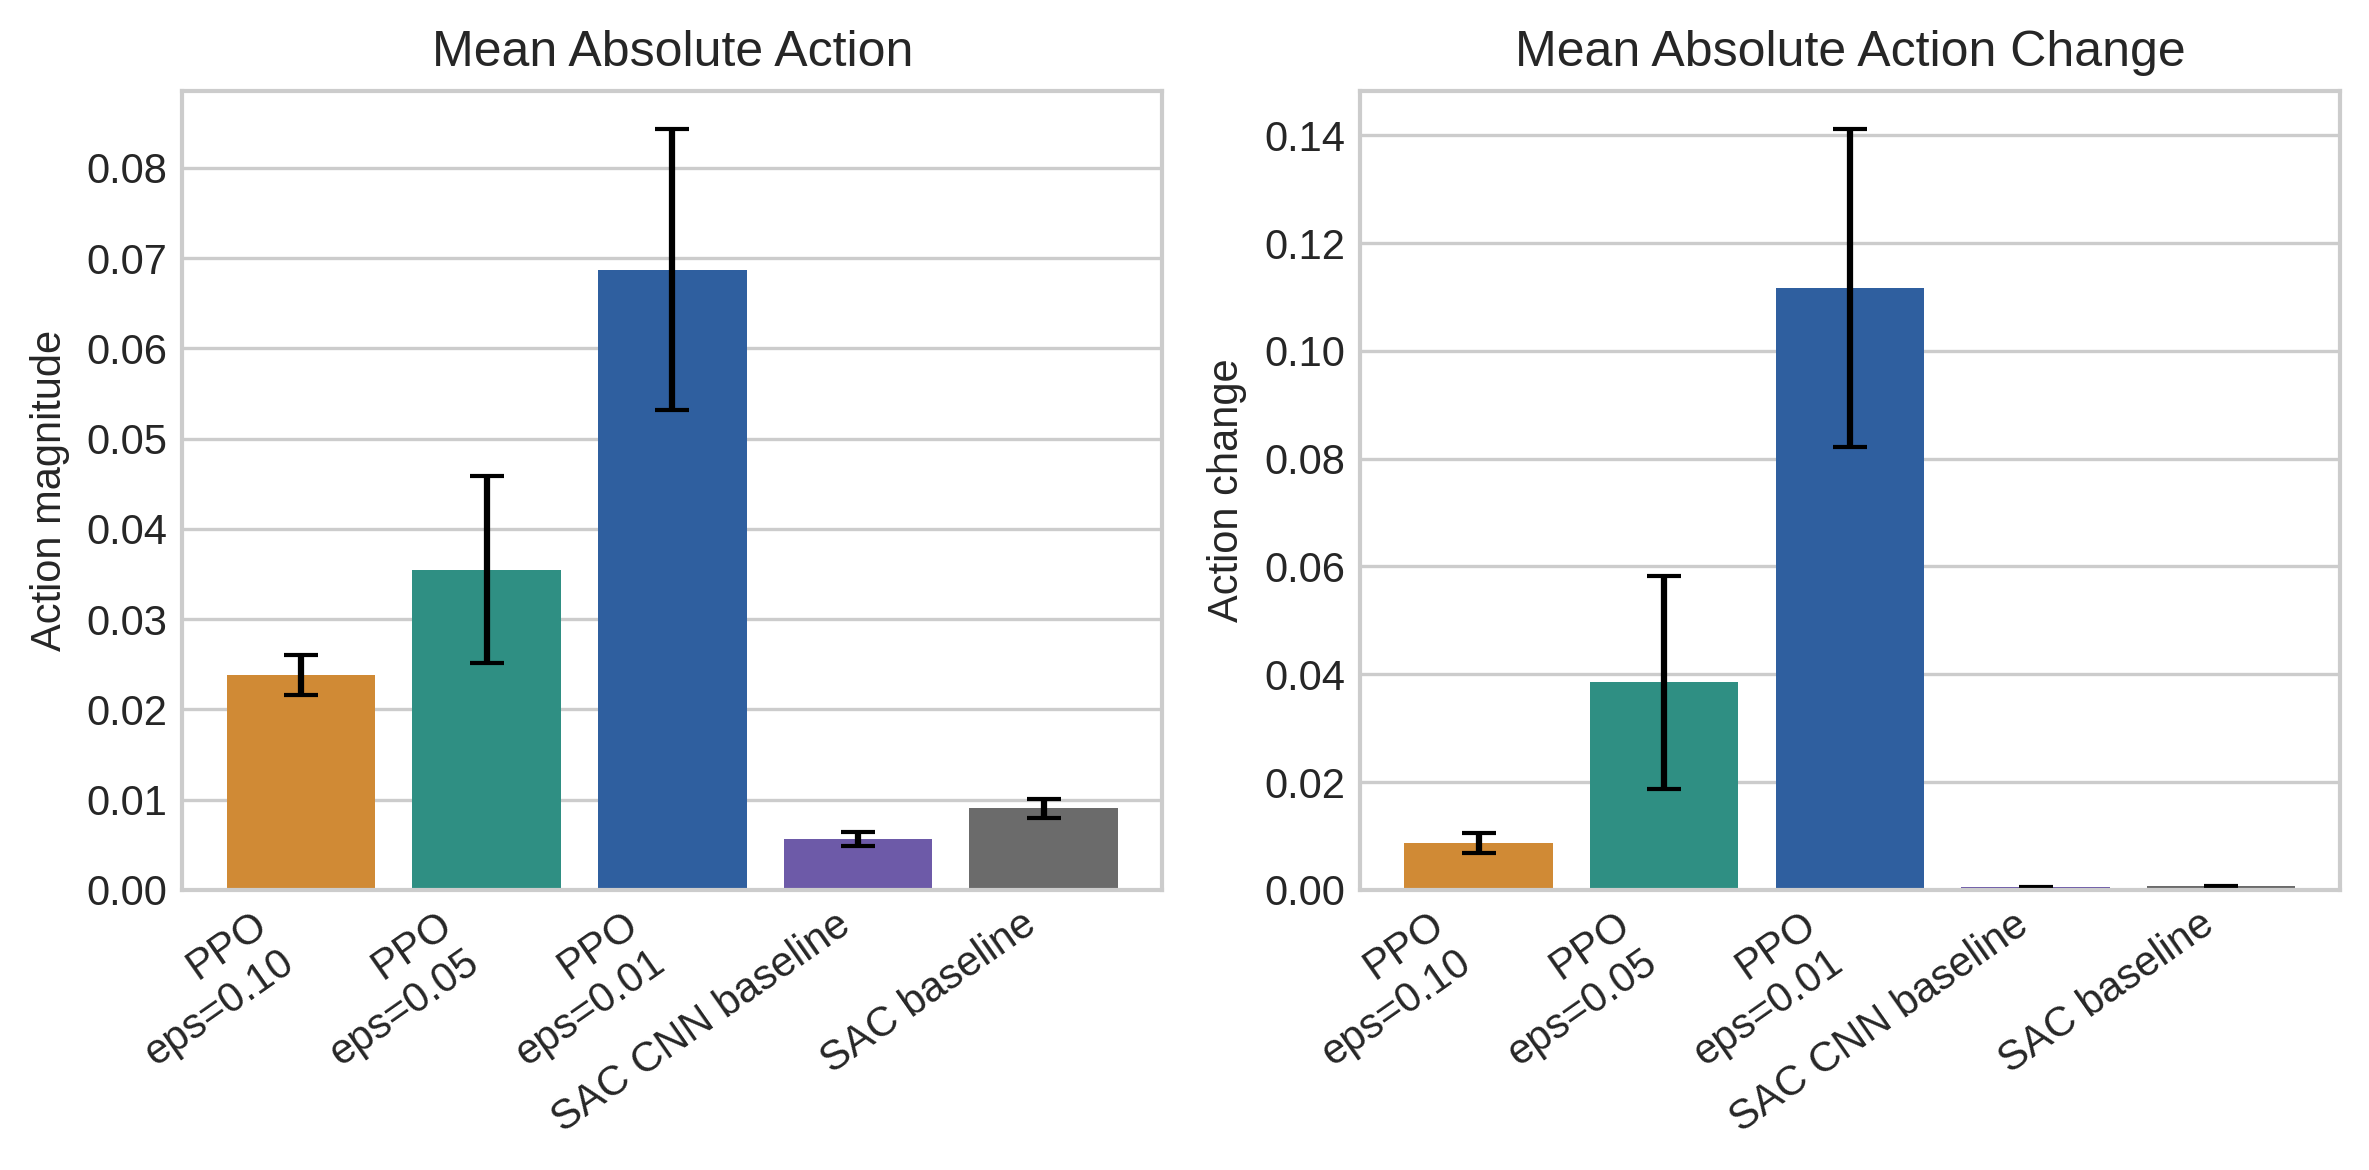

In [19]:
if RUN_RAW_TRACE_ANALYSIS:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), dpi=300)
    x = np.arange(len(trace_summary))
    labels = [label.replace("PPO staged ", "PPO\n") for label in trace_summary.index]
    colors = [PLOT_COLORS[idx] for idx in trace_summary.index]

    axes[0].bar(x, trace_summary["mean_abs_action"], yerr=trace_summary["mean_abs_action_ci95"], color=colors, capsize=4)
    axes[0].set_title("Mean Absolute Action")
    axes[0].set_ylabel("Action magnitude")

    axes[1].bar(
        x,
        trace_summary["mean_abs_action_change"],
        yerr=trace_summary["mean_abs_action_change_ci95"],
        color=colors,
        capsize=4,
    )
    axes[1].set_title("Mean Absolute Action Change")
    axes[1].set_ylabel("Action change")

    # axes[2].bar(x, trace_summary["q95_deviation"], color=colors)
    # axes[2].set_title("95th Percentile Height Deviation")
    # axes[2].set_ylabel("Deviation")

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=35, ha="right")
        ax.grid(axis="x", visible=False)

    fig.tight_layout()
    plt.show()
else:
    print("Smoothness plots skipped because RUN_RAW_TRACE_ANALYSIS is False.")